# Hardened Fixed-Point Perceptron Core for Secure Biomedical Edge-AI Anomaly Detection

**IEEE SSCS Open-Source Ecosystem — "Code-a-Chip" Travel Grant Award — ISSCC 2027**

**Author:** Juan Carlos Aquino Hernández — Universidad Tecnológica de Nayarit (UTNay), División de Electromecánica Industrial
**License:** Apache License 2.0 (see `LICENSE`) — Copyright 2026 Juan Carlos Aquino Hernández.
**Project context:** Sistema Auditable de Trazabilidad de Dispositivos Médicos (SATDM).

---

## Abstract

Local anomaly detection is crucial for protecting patient health in wearable medical devices and biomedical IoT
nodes. Putting decision logic into hardware can, however, create vulnerabilities: arithmetic overflow or
data-injection attacks may disrupt the system or silence alerts. This notebook implements and validates,
end-to-end and reproducibly with **100 % open-source EDA tools**, a hardware-hardening methodology for a
perceptron-based anomaly-detection core designed for resource-limited biomedical edge nodes:

- **Overflow-aware arithmetic**: 32-bit extended accumulation (overflow-free by construction for 8-bit operands)
  followed by a strict symmetric saturation stage. The saturator is reachable in narrower-accumulator variants
  through the `SAT_GUARD` parameter and is shown to clamp (instead of wrapping into a false negative) in §3.2.
- **Enable-gated functional isolation**: one control-register bit deterministically freezes/locks the alert line and
  the diagnostic registers, protecting against sensor-level denial-of-service and malicious data injection.
- **Full RTL-to-GDSII open-source ASIC flow** (LibreLane/OpenLane + SkyWater Sky130 PDK) with DRC/LVS signoff and
  setup/hold timing reported for **every PVT corner**.

**Every number in the result tables is read from a tool output** (cocotb, Yosys, OpenROAD, Magic, KLayout,
Netgen). The few figures quoted in the text of §5 come from the logged runs described there (re-runnable with
`RUN_SLEW_EXPERIMENT = True`).

## Notebook map

| § | Content | Output |
|---|---|---|
| 1 | Environment (Nix + LibreLane + Sky130 PDK), tool versions | `tool_versions.json` |
| 2 | RTL: `anomaly_core.v` | RTL file |
| 3.1 | 6 structural cocotb tests (Table 1 of the companion paper) | `results_table1.md` |
| 3.2 | Saturation actually clamps (narrow accumulator + negative control) | log |
| 3.3 | Synthetic vital-signs dataset → train → quantize → **RTL vs Python bit-exact on the full validation set** | `hw_accuracy_report.json` |
| 4 | RTL-to-GDSII (LibreLane, Sky130), clock period closed in all PVT corners | run directory |
| 5 | Signoff report (DRC / LVS / timing per corner / area / power) | `signoff_baseline.md` |
| 6 | Accumulator-width design-space sweep | `sweep_results.csv` |
| 7 | GDS 2D/3D viewer | PNG / HTML |
| 8 | Artifact bundle | `codeachip_artifacts.zip` |

**References**
1. J. C. Aquino Hernández, *"RTL Hardening Methodology for Secure Fixed-Point Edge AI Inference Engines: A
   Perceptron-Based Biomedical Case Study,"* 2026 (companion paper).
2. OpenFASOC `temp-sense-gen` — https://github.com/idea-fasoc/OpenFASOC (parametric sweep-and-validate methodology).
3. LibreLane — https://github.com/librelane/librelane · OpenLane — https://github.com/The-OpenROAD-Project/OpenLane
4. SkyWater Sky130 open PDK — https://github.com/google/skywater-pdk
5. OpenSTA — https://github.com/The-OpenROAD-Project/OpenSTA

Tool versions are printed by §1.4 and saved to `tool_versions.json`.

## Reproducibility

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Juan-AquinoH/sscs-ose-code-a-chip.github.io/blob/main/ISSCC27/submitted_notebooks/hardened_perceptron_anomaly_core/anomaly_core_codeachip.ipynb)

* **Runtime:** Google Colab, **CPU only** (no GPU or TPU is used; the whole flow is CPU-bound).
* **How to run:** *Runtime → Run all*, in order. Do not skip cells: later cells depend on files and
  functions created by earlier ones.
* **Expected time:** about 2 hours end to end on a free Colab CPU runtime
  (§1 toolchain ≈ 5 min; §4.3 baseline = up to 3 flow runs of ≈ 12 min each; §6 sweep = 5 flow runs of 12–16 min each).
* **If the runtime restarts:** `/nix` and `/content` are wiped. Re-run §1 and every cell after it.
* **Pinned versions:** LibreLane 3.0.14 and the Sky130 PDK hash are fixed in §1; the exact tool versions used
  are printed by §1.4 and saved to `tool_versions.json`.
* **No external accounts needed:** Google Drive backup is off by default (`BACKUP_TO_DRIVE = False`).
* **Outputs:** everything is bundled in `codeachip_artifacts.zip` (§8).

## 1. Environment Setup

Installs LibreLane with its full binary toolchain (Yosys, OpenROAD, Magic, Netgen, KLayout) through Nix and
downloads the Sky130 PDK, so anyone can reproduce the run (per Code-a-Chip guidelines). Run once per session
(≈ 5 min the first time). A Colab runtime restart wipes `/nix` and `/content`: re-run this section if that happens.

In [ ]:
# 1.1 Optional: back up run artifacts to Google Drive (off by default so reviewers are not prompted for access)
import os
BACKUP_TO_DRIVE = False
BACKUP_DIR = None
if BACKUP_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    BACKUP_DIR = "/content/drive/MyDrive/codeachip_runs"
    os.makedirs(BACKUP_DIR, exist_ok=True)
    print("Drive backup folder:", BACKUP_DIR)
else:
    print("Drive backup disabled (set BACKUP_TO_DRIVE = True to enable).")



Drive backup disabled (set BACKUP_TO_DRIVE = True to enable).


In [ ]:
# 1.2 Nix package manager + daemon (Colab has no systemd, so the daemon is started by hand)
import os, shutil, subprocess, tempfile, time
from pathlib import Path

NIX_BIN = "/nix/var/nix/profiles/default/bin"
SOCK = "/nix/var/nix/daemon-socket/socket"

# groupadd/addgroup live in /usr/sbin, which is not on Colab's default PATH
for p_ in (NIX_BIN, "/sbin", "/usr/sbin"):
    if p_ not in os.environ["PATH"].split(":"):
        os.environ["PATH"] = p_ + ":" + os.environ["PATH"]
os.environ["LOCALE_ARCHIVE"] = "/usr/lib/locale/locale-archive"

if not Path(f"{NIX_BIN}/nix").exists():
    with tempfile.TemporaryDirectory() as d:
        installer = Path(d) / "nix-installer"
        subprocess.run(["curl", "--proto", "=https", "--tlsv1.2", "-sSf", "-L",
                        "https://install.determinate.systems/nix", "-o", str(installer)], check=True)
        with open("/content/nix-installer.log", "w") as log:
            subprocess.run(
                ["bash", str(installer), "install", "--prefer-upstream-nix", "--no-confirm", "--extra-conf",
                 "extra-substituters = https://nix-cache.fossi-foundation.org\n"
                 "extra-trusted-public-keys = nix-cache.fossi-foundation.org:"
                 "3+K59iFwXqKsL7BNu6Guy0v+uTlwsxYQxjspXzqLYQs=\n"],
                stdout=log, stderr=subprocess.STDOUT)
    print(subprocess.run(["tail", "-n", "3", "/content/nix-installer.log"],
                         capture_output=True, text=True).stdout)
else:
    print("Nix already installed, skipping.")

assert Path(f"{NIX_BIN}/nix").exists(), "Nix was not installed: see /content/nix-installer.log"

if not os.path.exists(SOCK):
    subprocess.Popen([f"{NIX_BIN}/nix-daemon"], stdout=open("/content/nix-daemon.log", "w"),
                     stderr=subprocess.STDOUT, start_new_session=True)
    for _ in range(30):
        if os.path.exists(SOCK):
            break
        time.sleep(1)
assert os.path.exists(SOCK), "nix-daemon did not start: see /content/nix-daemon.log"
print("\u2713 Nix ready (binary and daemon verified).")


Nix already installed, skipping.
✓ Nix ready (binary and daemon verified).


In [ ]:
import os, sys, subprocess, time, yaml

print("=== 1b. Installing LibreLane + toolchain (Yosys/OpenROAD/Magic/Netgen/KLayout) via Nix ===")

NIX_BIN = "/nix/var/nix/profiles/default/bin"
SOCK = "/nix/var/nix/daemon-socket/socket"
assert os.path.exists(SOCK), "Run section 1.2 first (the Nix daemon is not running)"

LIBRELANE_VERSION = "3.0.14"
PDK_ROOT = os.path.expanduser("~/.ciel")
os.environ["PDK_ROOT"] = PDK_ROOT
PDK = "sky130"
librelane_src = os.path.join(os.getcwd(), "librelane_src")

subprocess.run(["rm", "-rf", librelane_src], check=False)
os.makedirs(librelane_src, exist_ok=True)
subprocess.run(
    f'curl -L "https://github.com/librelane/librelane/tarball/{LIBRELANE_VERSION}" '
    f'| tar -xzC "{librelane_src}" --strip-components 1',
    shell=True, check=True,
)

try:
    import tkinter  # noqa: F401
except ImportError:
    subprocess.run(["apt-get", "install", "-y", "-qq", "python3-tk"], check=False)

print("\nInstalling binary dependencies with Nix (.#colab-env)... this may take several minutes the first time.")
NIX_LOG = "/content/nix-install.log"
t0 = time.time()
with open(NIX_LOG, "w") as log:
    p = subprocess.Popen(
        ["nix", "profile", "install",
         "--extra-experimental-features", "nix-command flakes",
         "--accept-flake-config", ".#colab-env"],
        cwd=librelane_src, stdout=log, stderr=subprocess.STDOUT,
    )
    while p.poll() is None:
        time.sleep(30)
        print(f"  ... {int(time.time() - t0)} s, log: {os.path.getsize(NIX_LOG) // 1024} KB", flush=True)

if p.returncode != 0:
    print(subprocess.run(["tail", "-n", "40", NIX_LOG], capture_output=True, text=True).stdout)
    raise RuntimeError(f"nix profile install failed (rc={p.returncode}). Log: {NIX_LOG}")
print(f"  Nix OK en {int(time.time() - t0)} s")

print("\nInstalling the LibreLane Python package...")
subprocess.run(["pip3", "install", "-q", "."], cwd=librelane_src, check=True)

print("\nDownloading the Sky130 PDK (via ciel)...")
import ciel
from ciel.source import StaticWebDataSource

with open(os.path.join(librelane_src, "librelane", "pdk_hashes.yaml")) as f:
    pdk_hashes = yaml.safe_load(f)

ciel.enable(
    ciel.get_ciel_home(PDK_ROOT),
    PDK,
    pdk_hashes[PDK],
    data_source=StaticWebDataSource("https://fossi-foundation.github.io/ciel-releases"),
)

import shutil
tools = {t: shutil.which(t) for t in ("yosys", "openroad", "magic", "netgen", "klayout")}
print(tools)
assert all(tools.values()), f"Missing tools: {[k for k, v in tools.items() if not v]}"
print("\n\u2713 LibreLane + toolchain + PDK installed.")

=== 1b. Installing LibreLane + toolchain (Yosys/OpenROAD/Magic/Netgen/KLayout) via Nix ===

Installing binary dependencies with Nix (.#colab-env)... this may take several minutes the first time.
  ... 30 s, log: 0 KB
  Nix OK en 30 s

Installing the LibreLane Python package...



Version 8afc8346a57fe1ab7934ba5a6056ea8b43078e71 enabled for the sky130 PDK.

{'yosys': '/nix/var/nix/profiles/default/bin/yosys', 'openroad': '/nix/var/nix/profiles/default/bin/openroad', 'magic': '/nix/var/nix/profiles/default/bin/magic', 'netgen': '/nix/var/nix/profiles/default/bin/netgen', 'klayout': '/nix/var/nix/profiles/default/bin/klayout'}

✓ LibreLane + toolchain + PDK installed.


In [ ]:
import os, shutil, subprocess

assert os.path.exists("/nix/var/nix/daemon-socket/socket"), "nix-daemon is not running"
print("PDK_ROOT:", os.environ.get("PDK_ROOT"))
print("sky130A:", os.path.isdir(os.path.expanduser("~/.ciel/sky130A")))

for cmd in ("yosys -V", "openroad -version", "magic --version", "librelane --version"):
    r = subprocess.run(cmd, shell=True, capture_output=True, text=True, timeout=60)
    print(f"{cmd:22s} rc={r.returncode}  {(r.stdout or r.stderr).strip().splitlines()[0] if (r.stdout or r.stderr).strip() else ''}")

PDK_ROOT: /root/.ciel
sky130A: True
yosys -V               rc=0  Yosys 0.62 (git sha1 7326bb7d6641500ecb285c291a54a662cb1e76cf, clang++ 21.1.2 -fPIC -O3)
openroad -version      rc=0  dcf36133a369abc8f3c5e5738cd4d82e4903c0e0
magic --version        rc=0  8.3.623
librelane --version    rc=0  LibreLane v3.0.14


In [ ]:
# 1.4 Tool versions (saved for the report)
import subprocess, json, yaml
import librelane

def v(cmd):
    try:
        r = subprocess.run(cmd, capture_output=True, text=True, timeout=30)
        return (r.stdout or r.stderr).strip().splitlines()[0]
    except Exception as e:
        return f"N/A ({e})"

with open(os.path.join(os.getcwd(), "librelane_src", "librelane", "pdk_hashes.yaml")) as f:
    pdk_hash = yaml.safe_load(f).get("sky130")

TOOL_VERSIONS = {
    "librelane": librelane.__version__,
    "yosys":     v(["yosys", "-V"]),
    "openroad":  v(["openroad", "-version"]),
    "magic":     v(["magic", "--version"]),
    "netgen":    v(["netgen", "-batch", "version"]),
    "klayout":   v(["klayout", "-v"]),
    "sky130_pdk_ciel_hash": pdk_hash,
}
with open("tool_versions.json", "w") as f:
    json.dump(TOOL_VERSIONS, f, indent=2)
for k, val in TOOL_VERSIONS.items():
    print(f"{k:22s}: {val}")

librelane             : 3.0.14
yosys                 : Yosys 0.62 (git sha1 7326bb7d6641500ecb285c291a54a662cb1e76cf, clang++ 21.1.2 -fPIC -O3)
openroad              : dcf36133a369abc8f3c5e5738cd4d82e4903c0e0
magic                 : 8.3.623
netgen                : Netgen 1.5.316 compiled on Tue Feb 10 11:09:08 UTC 2026
klayout               : KLayout 0.30.7
sky130_pdk_ciel_hash  : 8afc8346a57fe1ab7934ba5a6056ea8b43078e71


## 2. RTL: Hardened Perceptron Anomaly-Detection Core

Datapath (Fig. 1 of the companion paper):

```
Biomedical Inputs -> Feature Registers -> MAC Unit -> Wide Accumulator
                                                              |
Anomaly Output <- Enable Gating <- Threshold Comparator <- Symmetric Saturation
```

- 4 signed 8-bit inputs `f_i` (Q1.7) and 4 signed 8-bit configurable weights `w_i` (Q1.7), 16-bit signed bias (Q1.15)
- **32-bit** accumulator (vs. a naive 16-bit design): with 8-bit operands |sum| ≤ 4·128² + 2¹⁵ = 98 304, so the
  accumulation cannot overflow by construction
- **Symmetric saturation** to `[-2^(ACC_W-1), 2^(ACC_W-1)-1]`. With `SAT_GUARD = 0` (baseline) the clamp is omitted
  because it would be constant-false at 32 bits; with `SAT_GUARD = 3` the sum is formed with 3 guard bits so the
  clamp is reachable when `ACC_W` is reduced (used in §3.2 and §6)
- **Enable-gated isolation**: `REG_CTRL[0]` deterministically freezes `anomaly_o`, `REG_SCORE` and `REG_EVENT_LAST`
  when de-asserted

In [ ]:
%%writefile anomaly_core.v
// -----------------------------------------------------------------------------
// anomaly_core.v
// Hardened fixed-point perceptron anomaly-detection core.
// 4-input perceptron: score = sum(f_i * w_i) + bias ; anomaly_o = (score > threshold)
// 32-bit extended accumulation + symmetric saturation + enable-gated isolation.
// -----------------------------------------------------------------------------
`timescale 1ns/1ps
module anomaly_core #(
    parameter N_INPUTS = 4,
    parameter DATA_W   = 8,   // Q1.7 signed input / weight width
    parameter BIAS_W    = 16, // Q1.15 signed bias width
    parameter ACC_W      = 32, // extended accumulator width
    parameter SAT_GUARD  = 0   // extra pre-saturation guard bits (0 = baseline; 3 makes the saturator reachable for narrow ACC_W)
) (
    input  wire                        clk,
    input  wire                        rst_n,

    // Wishbone-style register interface (simplified for this notebook)
    input  wire                        wb_we,
    input  wire [7:0]                  wb_addr,
    input  wire [31:0]                 wb_wdata,
    output reg  [31:0]                 wb_rdata,

    // Streaming biomedical feature inputs
    input  wire                        feat_valid,
    input  wire signed [DATA_W-1:0]    f0, f1, f2, f3,

    output wire                        anomaly_o
);

    // ---------------------------------------------------------------
    // Configuration / diagnostic registers (Wishbone-mapped)
    // ---------------------------------------------------------------
    reg signed [DATA_W-1:0] w0, w1, w2, w3;
    reg signed [BIAS_W-1:0] bias;
    reg signed [ACC_W-1:0]  threshold;
    reg                     reg_ctrl;        // REG_CTRL[0] : enable (1 = active)
    reg signed [ACC_W-1:0]  reg_score;       // last saturated score (diagnostic)
    reg [DATA_W-1:0]        reg_event_last;  // last event id / feature snapshot
    wire signed [31:0]      score_rd = reg_score; // sign-extended readback (matters when ACC_W < 32)

    localparam ADDR_W0        = 8'h00;
    localparam ADDR_W1        = 8'h04;
    localparam ADDR_W2        = 8'h08;
    localparam ADDR_W3        = 8'h0C;
    localparam ADDR_BIAS      = 8'h10;
    localparam ADDR_THRESHOLD = 8'h14;
    localparam ADDR_CTRL      = 8'h18;
    localparam ADDR_SCORE     = 8'h1C; // read-only
    localparam ADDR_EVENTLAST = 8'h20; // read-only

    always @(posedge clk or negedge rst_n) begin
        if (!rst_n) begin
            w0 <= 0; w1 <= 0; w2 <= 0; w3 <= 0;
            bias <= 0; threshold <= 0; reg_ctrl <= 1'b1;
        end else if (wb_we) begin
            case (wb_addr)
                ADDR_W0:        w0        <= wb_wdata[DATA_W-1:0];
                ADDR_W1:        w1        <= wb_wdata[DATA_W-1:0];
                ADDR_W2:        w2        <= wb_wdata[DATA_W-1:0];
                ADDR_W3:        w3        <= wb_wdata[DATA_W-1:0];
                ADDR_BIAS:      bias      <= wb_wdata[BIAS_W-1:0];
                ADDR_THRESHOLD: threshold <= wb_wdata[ACC_W-1:0];
                ADDR_CTRL:      reg_ctrl  <= wb_wdata[0];
                default: ;
            endcase
        end
    end

    always @(*) begin
        case (wb_addr)
            ADDR_W0:        wb_rdata = {{(32-DATA_W){w0[DATA_W-1]}}, w0};
            ADDR_W1:        wb_rdata = {{(32-DATA_W){w1[DATA_W-1]}}, w1};
            ADDR_W2:        wb_rdata = {{(32-DATA_W){w2[DATA_W-1]}}, w2};
            ADDR_W3:        wb_rdata = {{(32-DATA_W){w3[DATA_W-1]}}, w3};
            ADDR_BIAS:      wb_rdata = {{(32-BIAS_W){bias[BIAS_W-1]}}, bias};
            ADDR_THRESHOLD: wb_rdata = threshold;
            ADDR_CTRL:      wb_rdata = {31'b0, reg_ctrl};
            ADDR_SCORE:     wb_rdata = reg_ctrl ? score_rd : 32'b0;
            ADDR_EVENTLAST: wb_rdata = reg_ctrl ? {24'b0, reg_event_last} : 32'b0;
            default:        wb_rdata = 32'b0;
        endcase
    end

    // ---------------------------------------------------------------
    // MAC unit : 4x (8x8 -> 16b) products, summed with the 16b bias
    // ---------------------------------------------------------------
    wire signed [2*DATA_W-1:0] p0 = f0 * w0;
    wire signed [2*DATA_W-1:0] p1 = f1 * w1;
    wire signed [2*DATA_W-1:0] p2 = f2 * w2;
    wire signed [2*DATA_W-1:0] p3 = f3 * w3;

    // ---------------------------------------------------------------
    // Overflow mitigation layer: wide accumulation
    // Every term is sign-extended to SUM_W = ACC_W + SAT_GUARD bits before
    // summing. With ACC_W >= 18 and 8-bit operands the sum cannot overflow
    // by construction (|sum| <= 4*128*128 + 2^(BIAS_W-1)).
    // ---------------------------------------------------------------
    localparam SUM_W = ACC_W + SAT_GUARD;

    wire signed [SUM_W-1:0] acc_sum =
          {{(SUM_W-2*DATA_W){p0[2*DATA_W-1]}}, p0}
        + {{(SUM_W-2*DATA_W){p1[2*DATA_W-1]}}, p1}
        + {{(SUM_W-2*DATA_W){p2[2*DATA_W-1]}}, p2}
        + {{(SUM_W-2*DATA_W){p3[2*DATA_W-1]}}, p3}
        + {{(SUM_W-BIAS_W){bias[BIAS_W-1]}}, bias};

    // ---------------------------------------------------------------
    // Hardening layer 1: strict symmetric saturation to the ACC_W range.
    // The comparison is done on the SUM_W-bit value, so with SAT_GUARD > 0
    // an overflow of the ACC_W-bit range is detected and clamped instead of
    // wrapping (with SAT_GUARD = 0 the clamp is omitted because it would be
    // constant-false for the baseline 32-bit design: wide accumulation is what
    // prevents overflow there).
    // ---------------------------------------------------------------
    localparam signed [ACC_W-1:0] MAX_INT = {1'b0, {(ACC_W-1){1'b1}}}; // +2^(ACC_W-1) - 1
    localparam signed [ACC_W-1:0] MIN_INT = {1'b1, {(ACC_W-1){1'b0}}}; // -2^(ACC_W-1)

    wire signed [ACC_W-1:0] score_sat;

    generate
        if (SAT_GUARD == 0) begin : g_sat_baseline
            // Baseline: the ACC_W-bit sum cannot leave the ACC_W range for
            // these operand widths, so the clamp would be constant-false.
            assign score_sat = acc_sum;
        end else begin : g_sat_active
            wire signed [SUM_W-1:0] max_ext = MAX_INT;   // sign-extended limits
            wire signed [SUM_W-1:0] min_ext = MIN_INT;
            assign score_sat = (acc_sum > max_ext) ? MAX_INT :
                               (acc_sum < min_ext) ? MIN_INT :
                                                     acc_sum[ACC_W-1:0];
        end
    endgenerate

    // ---------------------------------------------------------------
    // Decision: Heaviside step activation vs. configurable threshold
    // ---------------------------------------------------------------
    wire raw_anomaly = (score_sat > threshold);

    // ---------------------------------------------------------------
    // Hardening layer 2: enable-gated functional isolation
    // ---------------------------------------------------------------
    assign anomaly_o = reg_ctrl ? raw_anomaly : 1'b0;

    always @(posedge clk or negedge rst_n) begin
        if (!rst_n) begin
            reg_score      <= 0;
            reg_event_last <= 0;
        end else if (feat_valid && reg_ctrl) begin
            reg_score      <= score_sat;
            reg_event_last <= f0; // simplified event snapshot for this notebook
        end
    end

endmodule

Overwriting anomaly_core.v


## 3. Functional Verification

### 3.1 Structural tests (the 6 test cases of Table 1 of the paper)

| Test Case ID | Validation Purpose |
|---|---|
| `test_anomaly_core_perceptron` | Standard linear classifier inference |
| `test_anomaly_core_negative_weight` | Sign arithmetic in negative quadrants |
| `test_anomaly_core_multiple_features` | Simultaneous activation of multiple features |
| `test_anomaly_core_overflow_edge` | Robustness against accumulator overflow |
| `test_anomaly_core_counters` | Statistical monitoring of AI metrics |
| `test_anomaly_core_edge_and_gating` | Immunity and isolation (enable gating) |

Implemented with `cocotb` + Icarus Verilog; the table below is parsed from the simulator output.

In [ ]:
# Installs cocotb + Icarus Verilog, and avoids the conflict with the iverilog bundled with Nix (LibreLane)
import subprocess, os

subprocess.run(["pip", "install", "-q", "cocotb==2.1.0", "cocotb-test", "--break-system-packages"])
subprocess.run(["apt-get", "-qq", "install", "-y", "iverilog", "libexpat1"], check=False)

# --- FIX: the Nix environment installed in Section 1 prepends /nix/.../bin to PATH.
# If that folder ships its own iverilog/vvp (linked against a different glibc than
# this image's), running it produces "stack smashing detected" when compiling and
# "__vdso_time: invalid mode for dlopen()" when simulating. We force the apt-get
# iverilog (compatible with the system) to take priority for EVERYTHING that follows
# in the notebook related to cocotb/Icarus.
os.environ["PATH"] = "/usr/bin:/usr/local/bin:" + os.environ.get("PATH", "")

print("=== Binaries that will be used ===")
subprocess.run(["bash", "-c", "which -a iverilog vvp"])
print()
subprocess.run(["bash", "-c", "ldd $(which vvp) 2>/dev/null | head -5"])

=== Binaries that will be used ===



CompletedProcess(args=['bash', '-c', 'ldd $(which vvp) 2>/dev/null | head -5'], returncode=0)

In [ ]:
# Records cocotb/Icarus versions in tool_versions.json (reproducibility).
import json, subprocess, cocotb
from importlib.metadata import version

tv = json.load(open("tool_versions.json"))
tv["cocotb"] = version("cocotb")
tv["iverilog"] = (subprocess.run(["iverilog", "-V"], capture_output=True, text=True).stdout or "N/A").splitlines()[0]
json.dump(tv, open("tool_versions.json", "w"), indent=2)
print({k: tv[k] for k in ("cocotb", "iverilog")})


{'cocotb': '2.1.0', 'iverilog': 'Icarus Verilog version 12.0 (stable) ()'}


In [ ]:
%%writefile test_anomaly_core.py
import cocotb
from cocotb.clock import Clock
from cocotb.triggers import RisingEdge

ADDR_W0, ADDR_W1, ADDR_W2, ADDR_W3 = 0x00, 0x04, 0x08, 0x0C
ADDR_BIAS, ADDR_THRESHOLD, ADDR_CTRL = 0x10, 0x14, 0x18
ADDR_SCORE, ADDR_EVENTLAST = 0x1C, 0x20

async def wb_write(dut, addr, data):
    dut.wb_addr.value = addr
    dut.wb_wdata.value = data & 0xFFFFFFFF
    dut.wb_we.value = 1
    await RisingEdge(dut.clk)
    dut.wb_we.value = 0

async def wb_read(dut, addr):
    dut.wb_addr.value = addr
    await RisingEdge(dut.clk)
    return int(dut.wb_rdata.value.signed_integer)

async def reset(dut):
    dut.rst_n.value = 0
    dut.feat_valid.value = 0
    dut.f0.value = 0; dut.f1.value = 0; dut.f2.value = 0; dut.f3.value = 0
    for _ in range(3):
        await RisingEdge(dut.clk)
    dut.rst_n.value = 1
    await RisingEdge(dut.clk)

def to_signed(val, bits):
    val &= (1 << bits) - 1
    if val & (1 << (bits - 1)):
        val -= (1 << bits)
    return val

@cocotb.test()
async def test_anomaly_core_perceptron(dut):
    # Standard linear classifier inference.
    cocotb.start_soon(Clock(dut.clk, 10, units="ns").start())
    await reset(dut)
    await wb_write(dut, ADDR_W0, 10); await wb_write(dut, ADDR_W1, 5)
    await wb_write(dut, ADDR_W2, 2);  await wb_write(dut, ADDR_W3, 1)
    await wb_write(dut, ADDR_BIAS, 0)
    await wb_write(dut, ADDR_THRESHOLD, 50)
    dut.f0.value = to_signed(10, 8) & 0xFF
    dut.f1.value = 0; dut.f2.value = 0; dut.f3.value = 0
    dut.feat_valid.value = 1
    await RisingEdge(dut.clk)
    dut.feat_valid.value = 0
    await RisingEdge(dut.clk)
    assert int(dut.anomaly_o.value) == 1, "Expected anomaly_o=1 for score=100 > threshold=50"

@cocotb.test()
async def test_anomaly_core_negative_weight(dut):
    # Sign arithmetic in negative quadrants.
    cocotb.start_soon(Clock(dut.clk, 10, units="ns").start())
    await reset(dut)
    await wb_write(dut, ADDR_W0, (-10) & 0xFF)
    await wb_write(dut, ADDR_W1, 0); await wb_write(dut, ADDR_W2, 0); await wb_write(dut, ADDR_W3, 0)
    await wb_write(dut, ADDR_BIAS, 0)
    await wb_write(dut, ADDR_THRESHOLD, 0)
    dut.f0.value = 10 & 0xFF
    dut.feat_valid.value = 1
    await RisingEdge(dut.clk)
    dut.feat_valid.value = 0
    await RisingEdge(dut.clk)
    score = await wb_read(dut, ADDR_SCORE)
    assert score == -100, f"Expected score=-100, got {score}"
    assert int(dut.anomaly_o.value) == 0, "Negative score must not trigger anomaly_o"

@cocotb.test()
async def test_anomaly_core_multiple_features(dut):
    # Simultaneous activation of multiple features.
    cocotb.start_soon(Clock(dut.clk, 10, units="ns").start())
    await reset(dut)
    for addr in (ADDR_W0, ADDR_W1, ADDR_W2, ADDR_W3):
        await wb_write(dut, addr, 20)
    await wb_write(dut, ADDR_BIAS, 0)
    await wb_write(dut, ADDR_THRESHOLD, 100)
    dut.f0.value = 5 & 0xFF; dut.f1.value = 5 & 0xFF
    dut.f2.value = 5 & 0xFF; dut.f3.value = 5 & 0xFF
    dut.feat_valid.value = 1
    await RisingEdge(dut.clk)
    dut.feat_valid.value = 0
    await RisingEdge(dut.clk)
    assert int(dut.anomaly_o.value) == 1

@cocotb.test()
async def test_anomaly_core_overflow_edge(dut):
    # Worst-case operands: score must stay positive and flag the anomaly (32-bit: no overflow possible).
    cocotb.start_soon(Clock(dut.clk, 10, units="ns").start())
    await reset(dut)
    for addr in (ADDR_W0, ADDR_W1, ADDR_W2, ADDR_W3):
        await wb_write(dut, addr, 127)      # max positive weight
    await wb_write(dut, ADDR_BIAS, 32767)   # max positive bias
    await wb_write(dut, ADDR_THRESHOLD, 1000)
    for sig in (dut.f0, dut.f1, dut.f2, dut.f3):
        sig.value = 127                     # max positive input
    dut.feat_valid.value = 1
    await RisingEdge(dut.clk)
    dut.feat_valid.value = 0
    await RisingEdge(dut.clk)
    # With saturation this must still read as a valid large positive value,
    # never a wrapped negative one.
    # 32-bit accumulator: worst case is representable (no clamp needed); saturation is exercised in 3.2.
    score = await wb_read(dut, ADDR_SCORE)
    assert score == 4 * 127 * 127 + 32767, f"unexpected score {score}"
    assert int(dut.anomaly_o.value) == 1, "Large-positive score must still flag anomaly"

@cocotb.test()
async def test_anomaly_core_counters(dut):
    # Statistical monitoring: REG_SCORE / REG_EVENT_LAST update on valid events.
    cocotb.start_soon(Clock(dut.clk, 10, units="ns").start())
    await reset(dut)
    await wb_write(dut, ADDR_W0, 1); await wb_write(dut, ADDR_W1, 0)
    await wb_write(dut, ADDR_W2, 0); await wb_write(dut, ADDR_W3, 0)
    await wb_write(dut, ADDR_BIAS, 0)
    await wb_write(dut, ADDR_THRESHOLD, 0)
    dut.f0.value = 42
    dut.feat_valid.value = 1
    await RisingEdge(dut.clk)
    dut.feat_valid.value = 0
    await RisingEdge(dut.clk)
    ev = await wb_read(dut, ADDR_EVENTLAST)
    assert ev == 42, f"Expected REG_EVENT_LAST=42, got {ev}"

@cocotb.test()
async def test_anomaly_core_edge_and_gating(dut):
    # Immunity and isolation: REG_CTRL[0]=0 must freeze/lock outputs and registers.
    cocotb.start_soon(Clock(dut.clk, 10, units="ns").start())
    await reset(dut)
    await wb_write(dut, ADDR_W0, 100)
    await wb_write(dut, ADDR_THRESHOLD, 0)
    await wb_write(dut, ADDR_CTRL, 0)   # disable / isolate
    dut.f0.value = 100
    dut.feat_valid.value = 1
    await RisingEdge(dut.clk)
    dut.feat_valid.value = 0
    await RisingEdge(dut.clk)
    assert int(dut.anomaly_o.value) == 0, "anomaly_o must be locked low while REG_CTRL[0]=0"
    score = await wb_read(dut, ADDR_SCORE)
    assert score == 0, "REG_SCORE must read back as locked (0) while disabled"

Overwriting test_anomaly_core.py


In [ ]:
%%writefile run_sim.py
import os
from pathlib import Path
from cocotb_tools.runner import get_runner


def run(test_module="test_anomaly_core", acc_w=None, sat_guard=None, build_dir="sim_build"):
    os.environ["PROJECT_DIR"] = str(Path.cwd())   # tests read/write files here (the simulator runs in build_dir)
    runner = get_runner(os.getenv("SIM", "icarus"))
    params = {}
    if acc_w:
        params["ACC_W"] = acc_w
    if sat_guard is not None:
        params["SAT_GUARD"] = sat_guard
    kw = {"parameters": params} if params else {}
    runner.build(
        sources=[Path("anomaly_core.v").resolve()],
        hdl_toplevel="anomaly_core",
        always=True,
        build_dir=build_dir,
        **kw,
    )
    runner.test(
        hdl_toplevel="anomaly_core",
        test_module=test_module,
        build_dir=build_dir,
    )


if __name__ == "__main__":
    acc, guard = os.getenv("ACC_W"), os.getenv("SAT_GUARD")
    run(os.getenv("TEST_MODULE", "test_anomaly_core"),
        int(acc) if acc else None,
        int(guard) if guard else None,
        os.getenv("BUILD_DIR", "sim_build"))

Overwriting run_sim.py


In [ ]:
import os, re, sys, subprocess
import pandas as pd

def parse_cocotb_results(output: str) -> pd.DataFrame:
    number = r"[-+]?(?:\d+(?:\.\d*)?|\.\d+)(?:[eE][-+]?\d+)?"
    pattern = re.compile(rf"\*\*\s+([\w.]+)\s+(PASS|FAIL|SKIP)\s+({number})\s+({number})\s+({number})\s+\*\*")
    rows = []
    for name, status, sim_t, real_t, ratio in pattern.findall(output):
        short = name.split(".")[-1].replace("test_anomaly_core_", "").replace("test_", "", 1)
        rows.append({"Test": short, "Status": status, "Sim Time (ns)": float(sim_t),
                     "Real Time (s)": float(real_t), "Ratio (ns/s)": float(ratio)})
    return pd.DataFrame(rows)

def run_cocotb(test_module, acc_w=None, sat_guard=None, build_dir="sim_build"):
    """Run one cocotb module through run_sim.py; returns (process, full_output, results_df)."""
    env = os.environ.copy()
    env.update(SIM="icarus", TEST_MODULE=test_module, BUILD_DIR=build_dir)
    env.pop("ACC_W", None); env.pop("SAT_GUARD", None)
    if acc_w:
        env["ACC_W"] = str(acc_w)
    if sat_guard is not None:
        env["SAT_GUARD"] = str(sat_guard)
    r = subprocess.run([sys.executable, "run_sim.py"], env=env, capture_output=True, text=True)
    out = (r.stdout or "") + "\n" + (r.stderr or "")
    return r, out, parse_cocotb_results(out)

def show_regression(title, r, out, df):
    print("=" * 64); print(f"  {title}"); print("=" * 64)
    if df.empty:
        print("No PASS/FAIL lines found. Return code:", r.returncode)
        print(out[-3000:])
        return False
    n_pass = int((df["Status"] == "PASS").sum())
    print(f"Tests: {len(df)}   PASS: {n_pass}   FAIL: {int((df['Status'] == 'FAIL').sum())}")
    display(df)
    return n_pass == len(df)

r, out, df_table1 = run_cocotb("test_anomaly_core")
ok = show_regression("ANOMALY CORE - STRUCTURAL REGRESSION (Table 1)", r, out, df_table1)
with open("results_table1.md", "w") as f:
    f.write(df_table1.to_markdown(index=False))
print("\n--- LaTeX ---\n")
print(df_table1.to_latex(index=False,
      caption="Cocotb regression results for the hardened perceptron anomaly-detection core.",
      label="tab:anomaly_core_results"))
assert ok, "Structural regression failed"

  ANOMALY CORE - STRUCTURAL REGRESSION (Table 1)
Tests: 6   PASS: 6   FAIL: 0


,Test,Status,Sim Time (ns),Real Time (s),Ratio (ns/s)
0,perceptron,PASS,110.0,0.01,11317.75
1,negative_weight,PASS,130.0,0.00,51228.78
2,multiple_features,PASS,120.0,0.01,20286.96
3,overflow_edge,PASS,130.0,0.00,67641.61
4,counters,PASS,130.0,0.00,62467.20
5,edge_and_gating,PASS,100.0,0.00,75661.39



--- LaTeX ---

\begin{table}
\caption{Cocotb regression results for the hardened perceptron anomaly-detection core.}
\label{tab:anomaly_core_results}
\begin{tabular}{llrrr}
\toprule
Test & Status & Sim Time (ns) & Real Time (s) & Ratio (ns/s) \\
\midrule
perceptron & PASS & 110.000000 & 0.010000 & 11317.750000 \\
negative_weight & PASS & 130.000000 & 0.000000 & 51228.780000 \\
multiple_features & PASS & 120.000000 & 0.010000 & 20286.960000 \\
overflow_edge & PASS & 130.000000 & 0.000000 & 67641.610000 \\
counters & PASS & 130.000000 & 0.000000 & 62467.200000 \\
edge_and_gating & PASS & 100.000000 & 0.000000 & 75661.390000 \\
\bottomrule
\end{tabular}
\end{table}



### 3.2 The saturator really clamps (and a plain wrap-around would not)

With the baseline 32-bit accumulator overflow is impossible, so this test deliberately **narrows the accumulator to
17 bits** and drives worst-case operands (`f = w = -128`, bias `+32767`; exact sum `98 303`). Two builds of the same
RTL are compared:

* `SAT_GUARD = 3` — the clamp is reachable: the score saturates at `+65 535` and the alert **stays asserted**.
* `SAT_GUARD = 0` (negative control) — the 17-bit sum wraps to `-32 769`: the alert is **silenced (false negative)**.
  The control is *expected to fail*; that failure is the evidence that saturation matters.

In [ ]:
%%writefile test_saturation.py
import cocotb
from cocotb.clock import Clock
from cocotb.triggers import RisingEdge, Timer

ACC_W = 17  # must match the ACC_W build parameter (SAT_GUARD=3 makes the clamp reachable)
ADDR_W0, ADDR_W1, ADDR_W2, ADDR_W3 = 0x00, 0x04, 0x08, 0x0C
ADDR_BIAS, ADDR_THRESHOLD, ADDR_CTRL, ADDR_SCORE = 0x10, 0x14, 0x18, 0x1C


def s32(v):
    v &= 0xFFFFFFFF
    return v - (1 << 32) if v & 0x80000000 else v


def wrap(v, bits):
    v &= (1 << bits) - 1
    return v - (1 << bits) if v & (1 << (bits - 1)) else v


async def wb_write(dut, addr, data):
    await RisingEdge(dut.clk)
    dut.wb_addr.value = addr
    dut.wb_wdata.value = data & 0xFFFFFFFF
    dut.wb_we.value = 1
    await RisingEdge(dut.clk)
    dut.wb_we.value = 0


async def reset(dut):
    dut.rst_n.value = 0
    dut.wb_we.value = 0
    dut.feat_valid.value = 0
    for p in (dut.f0, dut.f1, dut.f2, dut.f3):
        p.value = 0
    for _ in range(3):
        await RisingEdge(dut.clk)
    dut.rst_n.value = 1
    await RisingEdge(dut.clk)


async def apply(dut, f):
    await RisingEdge(dut.clk)
    for p, v in zip((dut.f0, dut.f1, dut.f2, dut.f3), f):
        p.value = v & 0xFF
    dut.feat_valid.value = 1
    dut.wb_addr.value = ADDR_SCORE
    await RisingEdge(dut.clk)
    await Timer(1, unit="ns")
    score = s32(int(dut.wb_rdata.value))
    alert = int(dut.anomaly_o.value)
    dut.feat_valid.value = 0
    return score, alert


@cocotb.test()
async def test_saturation_clamps_instead_of_wrapping(dut):
    """With a deliberately narrow accumulator the saturator must clamp.
    A plain wrap-around would turn a critical positive score negative
    (false negative); symmetric saturation must keep the alert asserted."""
    cocotb.start_soon(Clock(dut.clk, 10, unit="ns").start())
    await reset(dut)
    max_v, min_v = (1 << (ACC_W - 1)) - 1, -(1 << (ACC_W - 1))

    # --- positive overflow: 4*(-128*-128) + 32767 = 98303 > max_v
    for a in (ADDR_W0, ADDR_W1, ADDR_W2, ADDR_W3):
        await wb_write(dut, a, 0x80)          # w = -128
    await wb_write(dut, ADDR_BIAS, 32767)
    await wb_write(dut, ADDR_THRESHOLD, 0)
    await wb_write(dut, ADDR_CTRL, 1)
    exact = 4 * 128 * 128 + 32767
    score, alert = await apply(dut, [-128] * 4)
    wrapped = wrap(exact, ACC_W)
    dut._log.info(f"exact={exact} saturated={score} wrapped_would_be={wrapped} alert={alert}")
    assert exact > max_v, "operands do not overflow this ACC_W"
    assert wrapped <= 0, "wrap-around would NOT have produced a false negative here"
    assert score == max_v, f"positive clamp failed: {score} != {max_v}"
    assert alert == 1, "alert silenced by overflow (false negative)"

    # --- negative overflow: 4*(127*-128) + (-32768) = -97792 < min_v
    await wb_write(dut, ADDR_BIAS, -32768)
    score, alert = await apply(dut, [127] * 4)
    exact = 4 * (127 * -128) - 32768
    dut._log.info(f"exact={exact} saturated={score} alert={alert}")
    assert exact < min_v
    assert score == min_v, f"negative clamp failed: {score} != {min_v}"
    assert alert == 0

    # --- in-range operands are untouched
    await wb_write(dut, ADDR_BIAS, 0)
    score, alert = await apply(dut, [1, 2, 3, 4])
    assert score == -128 * (1 + 2 + 3 + 4), f"in-range score altered: {score}"

Overwriting test_saturation.py


In [ ]:
r, out, df_sat = run_cocotb("test_saturation", acc_w=17, sat_guard=3, build_dir="sim_build_sat")
ok = show_regression("SATURATION: ACC_W=17, SAT_GUARD=3 (clamp reachable)", r, out, df_sat)
for line in out.splitlines():
    if "exact=" in line:
        print("  ", line.strip().split("cocotb.anomaly_core")[-1].strip())
assert ok, "Saturation test failed with SAT_GUARD=3"

r0, out0, df_ctrl = run_cocotb("test_saturation", acc_w=17, sat_guard=0, build_dir="sim_build_sat0")
print("\nNEGATIVE CONTROL: ACC_W=17, SAT_GUARD=0 (no reachable clamp)")
for line in out0.splitlines():
    if "exact=" in line:
        print("  ", line.strip().split("cocotb.anomaly_core")[-1].strip())
assert not df_ctrl.empty and (df_ctrl["Status"] == "FAIL").all(), "control should FAIL (wrap-around -> false negative)"
print("Control failed as expected: without a reachable clamp the alert is silenced by the wrap-around.")

  SATURATION: ACC_W=17, SAT_GUARD=3 (clamp reachable)
Tests: 1   PASS: 1   FAIL: 0


,Test,Status,Sim Time (ns),Real Time (s),Ratio (ns/s)
0,saturation_clamps_instead_of_wrapping,PASS,271.0,0.01,36879.35


   exact=98303 saturated=65535 wrapped_would_be=-32769 alert=1
   exact=-97792 saturated=-65536 alert=0

NEGATIVE CONTROL: ACC_W=17, SAT_GUARD=0 (no reachable clamp)
   exact=98303 saturated=-32769 wrapped_would_be=-32769 alert=0
Control failed as expected: without a reachable clamp the alert is silenced by the wrap-around.


In [ ]:
%%writefile test_random_sat.py
import os, random
import cocotb
from cocotb.clock import Clock
from cocotb.triggers import RisingEdge, Timer

ACC_W = int(os.environ.get("ACC_W", "17"))
ADDR_W0, ADDR_W1, ADDR_W2, ADDR_W3 = 0x00, 0x04, 0x08, 0x0C
ADDR_BIAS, ADDR_THRESHOLD, ADDR_CTRL, ADDR_SCORE = 0x10, 0x14, 0x18, 0x1C


def s32(v):
    v &= 0xFFFFFFFF
    return v - (1 << 32) if v & 0x80000000 else v


async def wb_write(dut, addr, data):
    await RisingEdge(dut.clk)
    dut.wb_addr.value = addr
    dut.wb_wdata.value = data & 0xFFFFFFFF
    dut.wb_we.value = 1
    await RisingEdge(dut.clk)
    dut.wb_we.value = 0


async def reset(dut):
    dut.rst_n.value = 0
    dut.wb_we.value = 0
    dut.feat_valid.value = 0
    for p in (dut.f0, dut.f1, dut.f2, dut.f3):
        p.value = 0
    for _ in range(3):
        await RisingEdge(dut.clk)
    dut.rst_n.value = 1
    await RisingEdge(dut.clk)


async def run_vector(dut, f):
    await RisingEdge(dut.clk)
    for p, v in zip((dut.f0, dut.f1, dut.f2, dut.f3), f):
        p.value = v & 0xFF
    dut.feat_valid.value = 1
    dut.wb_addr.value = ADDR_SCORE
    await RisingEdge(dut.clk)
    await Timer(1, unit="ns")
    score, alert = s32(int(dut.wb_rdata.value)), int(dut.anomaly_o.value)
    dut.feat_valid.value = 0
    return score, alert


@cocotb.test()
async def test_random_vs_saturating_model(dut):
    cocotb.start_soon(Clock(dut.clk, 10, unit="ns").start())
    rng = random.Random(2027)
    await reset(dut)
    mx, mn = (1 << (ACC_W - 1)) - 1, -(1 << (ACC_W - 1))
    ext = [-128, -127, -1, 0, 1, 126, 127]
    pick = lambda: rng.choice(ext) if rng.random() < 0.5 else rng.randint(-128, 127)
    bad = n = sat_hits = 0
    for _ in range(60):
        w = [pick() for _ in range(4)]
        bias = rng.choice([-32768, 32767, rng.randint(-32768, 32767)])
        thr = rng.randint(mn // 2, mx // 2)
        for a, v in zip((ADDR_W0, ADDR_W1, ADDR_W2, ADDR_W3), w):
            await wb_write(dut, a, v & 0xFF)
        await wb_write(dut, ADDR_BIAS, bias & 0xFFFF)
        await wb_write(dut, ADDR_THRESHOLD, thr & 0xFFFFFFFF)
        await wb_write(dut, ADDR_CTRL, 1)
        for _ in range(40):
            f = [pick() for _ in range(4)]
            exact = sum(a * b for a, b in zip(f, w)) + bias
            exp = max(min(exact, mx), mn)
            sat_hits += int(exp != exact)
            score, alert = await run_vector(dut, f)
            n += 1
            bad += int(score != exp or alert != int(exp > thr))
    dut._log.info(f"vectors={n} saturated={sat_hits} mismatches={bad}")
    assert sat_hits > 0, "stimulus never reached the saturator"
    assert bad == 0, f"{bad}/{n} mismatches vs saturating model"


Overwriting test_random_sat.py


In [ ]:
r, out, df_rs = run_cocotb("test_random_sat", acc_w=17, sat_guard=3, build_dir="sim_build_rs3")
ok = show_regression("RANDOM vs SATURATING MODEL: ACC_W=17, SAT_GUARD=3", r, out, df_rs)
for line in out.splitlines():
    if "vectors=" in line:
        print("  ", line.strip().split("cocotb.anomaly_core")[-1].strip())
assert ok, "Random saturation equivalence failed with SAT_GUARD=3"

r0, out0, df_rs0 = run_cocotb("test_random_sat", acc_w=17, sat_guard=0, build_dir="sim_build_rs0")
for line in out0.splitlines():
    if "vectors=" in line:
        print("  control:", line.strip().split("cocotb.anomaly_core")[-1].strip())
assert not df_rs0.empty and (df_rs0["Status"] == "FAIL").all(), "control should FAIL"
print("Control failed as expected (wrap-around without a live clamp).")


  RANDOM vs SATURATING MODEL: ACC_W=17, SAT_GUARD=3
Tests: 1   PASS: 1   FAIL: 0


,Test,Status,Sim Time (ns),Real Time (s),Ratio (ns/s)
0,random_vs_saturating_model,PASS,56431.0,0.85,66324.76


   vectors=2400 saturated=22 mismatches=0
  control: vectors=2400 saturated=22 mismatches=22
Control failed as expected (wrap-around without a live clamp).


### 3.3 End-to-end accuracy with a trained model — bit-exact against the Python reference

Pipeline: synthetic vital-signs dataset (HR, SpO₂, temperature, HRV deviations) → scikit-learn perceptron →
int8/int16 quantization → Python reference model → **the full validation set (1 000 vectors) is streamed through
the RTL** over the Wishbone-style interface. The RTL must reproduce the reference score and decision *bit-exactly*;
a second, constrained-random test (1 600 vectors with extreme weights/bias/threshold) checks the RTL against a
32-bit saturating model.

In [ ]:
"""
generate_dataset.py
Generates a synthetic vital-signs dataset (4 features, binary normal/anomaly)
compatible with the 4 inputs of anomaly_core (f0..f3).

Features (deviation from baseline, already normalized to [-1, 1]):
  f0: heart rate (HR) deviation
  f1: SpO2 drop (negative = more severe)
  f2: body temperature deviation
  f3: heart rate variability (HRV) deviation

The label (anomaly) is generated with a hidden linear rule + noise, so that
it is learnable by a perceptron but not trivially 100% separable.

Usage:
    python3 generate_dataset.py --n 4000 --seed 42 --out dataset.csv
"""
import argparse
import csv
import numpy as np


def generate(n_samples: int, seed: int):
    rng = np.random.default_rng(seed)

    # Base distribution: most samples are "normal" (small variation),
    # a fraction are "events" with larger deviations in one or more signals.
    n_normal = int(n_samples * 0.75)
    n_event = n_samples - n_normal

    normal = rng.normal(loc=0.0, scale=0.15, size=(n_normal, 4))

    event = np.zeros((n_event, 4))
    for i in range(n_event):
        # each event affects 1-3 channels with strong magnitude
        n_channels = rng.integers(1, 4)
        channels = rng.choice(4, size=n_channels, replace=False)
        for ch in channels:
            sign = -1.0 if ch == 1 else rng.choice([-1.0, 1.0])  # SpO2 (f1) almost always drops
            event[i, ch] = sign * rng.uniform(0.5, 1.0)
        # background noise in the unaffected channels
        for ch in range(4):
            if ch not in channels:
                event[i, ch] = rng.normal(0.0, 0.15)

    X = np.vstack([normal, event])
    X = np.clip(X, -1.0, 1.0)

    # Hidden severity rule (not used directly by the trained perceptron,
    # only to generate the ground-truth label with observation noise)
    hidden_weights = np.array([0.9, -1.2, 0.7, 0.6])  # SpO2 weighs more and in the negative direction
    severity = X @ hidden_weights
    noise = rng.normal(0.0, 0.25, size=severity.shape)
    y = (severity + noise > 0.55).astype(int)

    idx = rng.permutation(n_samples)
    return X[idx], y[idx]


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--n", type=int, default=4000)
    ap.add_argument("--seed", type=int, default=42)
    ap.add_argument("--out", type=str, default="dataset.csv")

    args, unknown = ap.parse_known_args()

    X, y = generate(args.n, args.seed)

    with open(args.out, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["f0_hr", "f1_spo2", "f2_temp", "f3_hrv", "label"])
        for row, label in zip(X, y):
            w.writerow([*row.tolist(), int(label)])

    print(f"Dataset generated: {args.out}")
    print(f"  Samples: {len(y)}  |  Anomalies: {y.sum()} ({100*y.mean():.1f}%)")


if __name__ == "__main__":
    main()

Dataset generated: dataset.csv
  Samples: 4000  |  Anomalies: 668 (16.7%)


In [ ]:
import argparse
import json
import csv
import numpy as np
from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score

INT8_MIN, INT8_MAX = -128, 127
INT16_MIN, INT16_MAX = -32768, 32767


def load_dataset(path):
    X, y = [], []

    with open(path, newline="") as f:
        reader = csv.DictReader(f)

        for row in reader:
            X.append([
                float(row["f0_hr"]),
                float(row["f1_spo2"]),
                float(row["f2_temp"]),
                float(row["f3_hrv"])
            ])
            y.append(int(row["label"]))

    return np.array(X), np.array(y)


def quantize_to_int8(values, scale):
    q = np.round(np.asarray(values) * scale)
    return np.clip(q, INT8_MIN, INT8_MAX).astype(int)


def quantize_bias_to_int16(bias, scale):
    q = int(round(bias * scale))
    return int(np.clip(q, INT16_MIN, INT16_MAX))


def main():

    # ---------------------------------------------------------
    # 1. ARGUMENTS
    # ---------------------------------------------------------

    ap = argparse.ArgumentParser()

    ap.add_argument(
        "--dataset",
        default="dataset.csv"
    )

    ap.add_argument(
        "--out-params",
        default="trained_params.json"
    )

    ap.add_argument(
        "--out-vectors",
        default="validation_vectors.json"
    )

    ap.add_argument(
        "--test-size",
        type=float,
        default=0.25
    )

    ap.add_argument(
        "--seed",
        type=int,
        default=42
    )

    # IMPORTANT:
    # parse_known_args() allows ignoring the -f argument
    # that Google Colab/Jupyter adds.
    args, unknown = ap.parse_known_args()


    # ---------------------------------------------------------
    # 2. LOAD DATASET
    # ---------------------------------------------------------

    X, y = load_dataset(args.dataset)

    print("=== Dataset ===")
    print(f"Total samples:    {len(y)}")
    print(f"Normal:           {np.sum(y == 0)} ({100*np.mean(y == 0):.2f}%)")
    print(f"Anomalies:        {np.sum(y == 1)} ({100*np.mean(y == 1):.2f}%)")


    # ---------------------------------------------------------
    # 3. TRAINING / VALIDATION SPLIT
    # ---------------------------------------------------------

    X_train, X_val, y_train, y_val = train_test_split(
        X,
        y,
        test_size=args.test_size,
        random_state=args.seed,
        stratify=y
    )

    print()
    print("=== Dataset split ===")
    print(f"Training:   {len(y_train)}")
    print(f"Validation: {len(y_val)}")


    # ---------------------------------------------------------
    # 4. PERCEPTRON TRAINING
    # ---------------------------------------------------------

    clf = Perceptron(
        max_iter=2000,
        tol=1e-4,
        random_state=args.seed,
        class_weight="balanced"
    )

    clf.fit(X_train, y_train)

    y_pred_float = clf.predict(X_val)

    acc_float = accuracy_score(y_val, y_pred_float)

    precision_float = precision_score(
        y_val,
        y_pred_float,
        zero_division=0
    )

    recall_float = recall_score(
        y_val,
        y_pred_float,
        zero_division=0
    )

    f1_float = f1_score(
        y_val,
        y_pred_float,
        zero_division=0
    )

    w_float = clf.coef_[0]
    b_float = clf.intercept_[0]

    threshold_int = 0


    # ---------------------------------------------------------
    # 5. WEIGHT QUANTIZATION
    # ---------------------------------------------------------

    w_scale = (
        INT8_MAX /
        max(np.max(np.abs(w_float)), 1e-9)
    )

    w_q = quantize_to_int8(
        w_float,
        w_scale
    )


    # ---------------------------------------------------------
    # 6. FEATURE QUANTIZATION
    # ---------------------------------------------------------

    # X is normalized to [-1, 1]

    f_scale = INT8_MAX

    X_val_q = quantize_to_int8(
        X_val,
        f_scale
    )


    # ---------------------------------------------------------
    # 7. BIAS QUANTIZATION
    # ---------------------------------------------------------

    combined_scale = f_scale * w_scale

    b_q = int(
        np.clip(
            round(b_float * combined_scale),
            INT16_MIN,
            INT16_MAX
        )
    )


    # ---------------------------------------------------------
    # 8. QUANTIZED INFERENCE
    # ---------------------------------------------------------

    def hw_infer(features_row):

        score = int(
            np.sum(
                features_row.astype(np.int64)
                *
                w_q.astype(np.int64)
            )
        ) + b_q

        # 32-bit saturation

        score = max(
            min(score, 2**31 - 1),
            -2**31
        )

        return 1 if score > threshold_int else 0


    y_pred_quant = np.array([
        hw_infer(row)
        for row in X_val_q
    ])


    # ---------------------------------------------------------
    # 9. QUANTIZED METRICS
    # ---------------------------------------------------------

    acc_quant = accuracy_score(
        y_val,
        y_pred_quant
    )

    precision_quant = precision_score(
        y_val,
        y_pred_quant,
        zero_division=0
    )

    recall_quant = recall_score(
        y_val,
        y_pred_quant,
        zero_division=0
    )

    f1_quant = f1_score(
        y_val,
        y_pred_quant,
        zero_division=0
    )

    cm = confusion_matrix(
        y_val,
        y_pred_quant
    )


    # ---------------------------------------------------------
    # 10. EXPORT PARAMETERS
    # ---------------------------------------------------------

    params = {

        "w0": int(w_q[0]),
        "w1": int(w_q[1]),
        "w2": int(w_q[2]),
        "w3": int(w_q[3]),

        "bias": int(b_q),

        "threshold": int(threshold_int),

        "feature_scale": int(f_scale),

        "weight_scale": float(w_scale),

        "accuracy_float": float(acc_float),

        "precision_float": float(precision_float),

        "recall_float": float(recall_float),

        "f1_float": float(f1_float),

        "accuracy_quantized": float(acc_quant),

        "precision_quantized": float(precision_quant),

        "recall_quantized": float(recall_quant),

        "f1_quantized": float(f1_quant),

        "n_training_samples": int(len(y_train)),

        "n_validation_samples": int(len(y_val)),

        "n_total_samples": int(len(y))
    }


    with open(
        args.out_params,
        "w"
    ) as f:

        json.dump(
            params,
            f,
            indent=2
        )


    # ---------------------------------------------------------
    # 11. EXPORT VECTORS FOR RTL
    # ---------------------------------------------------------

    vectors = [

        {
            "f0": int(r[0]),
            "f1": int(r[1]),
            "f2": int(r[2]),
            "f3": int(r[3]),
            "label": int(lbl)
        }

        for r, lbl in zip(
            X_val_q,
            y_val
        )
    ]


    with open(
        args.out_vectors,
        "w"
    ) as f:

        json.dump(
            vectors,
            f,
            indent=2
        )


    # ---------------------------------------------------------
    # 12. RESULTS
    # ---------------------------------------------------------

    print()
    print("========================================")
    print("         TRAINING COMPLETED")
    print("========================================")

    print()
    print("Float weights:")
    print(
        f"w0={w_float[0]:.6f} "
        f"w1={w_float[1]:.6f} "
        f"w2={w_float[2]:.6f} "
        f"w3={w_float[3]:.6f}"
    )

    print()
    print("Quantized weights Q1.7 / int8:")
    print(
        f"w0={w_q[0]} "
        f"w1={w_q[1]} "
        f"w2={w_q[2]} "
        f"w3={w_q[3]}"
    )

    print()
    print(f"Float bias:       {b_float:.6f}")
    print(f"Quantized bias:   {b_q}")
    print(f"Threshold:        {threshold_int}")

    print()
    print("----- FLOAT -----")
    print(f"Accuracy:  {acc_float*100:.2f}%")
    print(f"Precision: {precision_float*100:.2f}%")
    print(f"Recall:    {recall_float*100:.2f}%")
    print(f"F1-score:  {f1_float*100:.2f}%")

    print()
    print("----- QUANTIZED / RTL -----")
    print(f"Accuracy:  {acc_quant*100:.2f}%")
    print(f"Precision: {precision_quant*100:.2f}%")
    print(f"Recall:    {recall_quant*100:.2f}%")
    print(f"F1-score:  {f1_quant*100:.2f}%")

    print()
    print(
        "Quantized confusion matrix "
        "[rows=actual, columns=predicted]:"
    )

    print(cm)

    print()
    print(f"Parameters -> {args.out_params}")
    print(
        f"Validation vectors "
        f"({len(vectors)}) -> {args.out_vectors}"
    )


if __name__ == "__main__":
    main()

=== Dataset ===
Total samples:    4000
Normal:           3332 (83.30%)
Anomalies:        668 (16.70%)

=== Dataset split ===
Training:   3000
Validation: 1000

         TRAINING COMPLETED

Float weights:
w0=6.553627 w1=-8.714994 w2=0.410446 w3=0.894711

Quantized weights Q1.7 / int8:
w0=96 w1=-127 w2=6 w3=13

Float bias:       -1.240017
Quantized bias:   -2295
Threshold:        0

----- FLOAT -----
Accuracy:  81.00%
Precision: 46.35%
Recall:    87.43%
F1-score:  60.58%

----- QUANTIZED / RTL -----
Accuracy:  81.30%
Precision: 46.79%
Recall:    87.43%
F1-score:  60.96%

Quantized confusion matrix [rows=actual, columns=predicted]:
[[667 166]
 [ 21 146]]

Parameters -> trained_params.json
Validation vectors (1000) -> validation_vectors.json


In [ ]:
import json
import numpy as np

# ============================================================
# PYTHON REFERENCE MODEL
# ============================================================

PARAMS_FILE = "trained_params.json"
VECTORS_FILE = "validation_vectors.json"


# ------------------------------------------------------------
# 1. Load parameters
# ------------------------------------------------------------

with open(PARAMS_FILE, "r") as f:
    params = json.load(f)

w0 = int(params["w0"])
w1 = int(params["w1"])
w2 = int(params["w2"])
w3 = int(params["w3"])

bias = int(params["bias"])
threshold = int(params["threshold"])

print("=== MODEL PARAMETERS ===")
print(f"w0        = {w0}")
print(f"w1        = {w1}")
print(f"w2        = {w2}")
print(f"w3        = {w3}")
print(f"bias      = {bias}")
print(f"threshold = {threshold}")


# ------------------------------------------------------------
# 2. Load validation vectors
# ------------------------------------------------------------

with open(VECTORS_FILE, "r") as f:
    vectors = json.load(f)

print()
print(f"Vectors loaded: {len(vectors)}")


# ------------------------------------------------------------
# 3. Reference model
# ------------------------------------------------------------

def reference_model(f0, f1, f2, f3):

    # 8 x 8 bit products
    p0 = f0 * w0
    p1 = f1 * w1
    p2 = f2 * w2
    p3 = f3 * w3

    # Accumulator
    score = p0 + p1 + p2 + p3 + bias

    # Classification
    prediction = 1 if score > threshold else 0

    return score, prediction


# ------------------------------------------------------------
# 4. Generate reference predictions
# ------------------------------------------------------------

reference_results = []

for i, v in enumerate(vectors):

    score, prediction = reference_model(
        v["f0"],
        v["f1"],
        v["f2"],
        v["f3"]
    )

    reference_results.append({
        "index": i,
        "f0": v["f0"],
        "f1": v["f1"],
        "f2": v["f2"],
        "f3": v["f3"],
        "label": v["label"],
        "score": score,
        "prediction": prediction
    })


# ------------------------------------------------------------
# 5. Show first results
# ------------------------------------------------------------

print()
print("=== FIRST 10 VECTORS ===")

for r in reference_results[:10]:

    print(
        f'{r["index"]:4d} | '
        f'f0={r["f0"]:4d} '
        f'f1={r["f1"]:4d} '
        f'f2={r["f2"]:4d} '
        f'f3={r["f3"]:4d} | '
        f'score={r["score"]:7d} | '
        f'label={r["label"]} | '
        f'pred={r["prediction"]}'
    )


# ------------------------------------------------------------
# 6. Save results
# ------------------------------------------------------------

with open("reference_results.json", "w") as f:
    json.dump(reference_results, f, indent=2)

print()
print("Python reference saved to:")
print("reference_results.json")

=== MODEL PARAMETERS ===
w0        = 96
w1        = -127
w2        = 6
w3        = 13
bias      = -2295
threshold = 0

Vectors loaded: 1000

=== FIRST 10 VECTORS ===
   0 | f0=  29 f1=  19 f2=  11 f3= -16 | score=  -2066 | label=0 | pred=0
   1 | f0=   8 f1= -10 f2=  11 f3=   7 | score=   -100 | label=0 | pred=0
   2 | f0= 109 f1=   1 f2=  -2 f3=  27 | score=   8381 | label=1 | pred=1
   3 | f0=   7 f1=   0 f2= -28 f3= -24 | score=  -2103 | label=0 | pred=0
   4 | f0= -83 f1= -69 f2=-116 f3=   3 | score=  -2157 | label=0 | pred=0
   5 | f0=  17 f1= -23 f2=  -5 f3= -11 | score=   2085 | label=0 | pred=1
   6 | f0=  78 f1=   0 f2=  21 f3= 110 | score=   6749 | label=1 | pred=1
   7 | f0=   0 f1=  55 f2=  24 f3= -11 | score=  -9279 | label=0 | pred=0
   8 | f0=   5 f1=  -8 f2= -12 f3= -35 | score=  -1326 | label=0 | pred=0
   9 | f0= -29 f1=  28 f2=  14 f3=-121 | score= -10124 | label=0 | pred=0

Python reference saved to:
reference_results.json


In [ ]:
%%writefile tb_dataset_full.py
import json
import os
import random
from pathlib import Path
import cocotb
from cocotb.clock import Clock
from cocotb.triggers import RisingEdge, Timer

ADDR_W0, ADDR_W1, ADDR_W2, ADDR_W3 = 0x00, 0x04, 0x08, 0x0C
ADDR_BIAS, ADDR_THRESHOLD, ADDR_CTRL, ADDR_SCORE = 0x10, 0x14, 0x18, 0x1C

# run_sim.py sets PROJECT_DIR to the notebook directory (the simulator itself runs inside build_dir)
ROOT = Path(os.environ.get("PROJECT_DIR", "."))

def s32(v):
    v &= 0xFFFFFFFF
    return v - (1 << 32) if v & 0x80000000 else v

def u8(v):
    return v & 0xFF

async def wb_write(dut, addr, data):
    await RisingEdge(dut.clk)
    dut.wb_addr.value = addr
    dut.wb_wdata.value = data & 0xFFFFFFFF
    dut.wb_we.value = 1
    await RisingEdge(dut.clk)
    dut.wb_we.value = 0

async def reset(dut):
    dut.rst_n.value = 0
    dut.wb_we.value = 0
    dut.feat_valid.value = 0
    for p in (dut.f0, dut.f1, dut.f2, dut.f3):
        p.value = 0
    for _ in range(3):
        await RisingEdge(dut.clk)
    dut.rst_n.value = 1
    await RisingEdge(dut.clk)

async def configure(dut, w, bias, threshold):
    for addr, v in zip((ADDR_W0, ADDR_W1, ADDR_W2, ADDR_W3), w):
        await wb_write(dut, addr, u8(v))
    await wb_write(dut, ADDR_BIAS, bias & 0xFFFF)
    await wb_write(dut, ADDR_THRESHOLD, threshold & 0xFFFFFFFF)
    await wb_write(dut, ADDR_CTRL, 1)

async def run_vector(dut, f):
    """Apply one feature vector; return (score read via Wishbone, anomaly_o)."""
    await RisingEdge(dut.clk)
    for p, v in zip((dut.f0, dut.f1, dut.f2, dut.f3), f):
        p.value = u8(v)
    dut.feat_valid.value = 1
    dut.wb_addr.value = ADDR_SCORE
    await RisingEdge(dut.clk)            # reg_score captured on this edge
    await Timer(1, unit="ns")
    score = s32(int(dut.wb_rdata.value))
    alert = int(dut.anomaly_o.value)
    dut.feat_valid.value = 0
    return score, alert

@cocotb.test()
async def test_validation_set_bit_exact(dut):
    """Run the whole validation set through the RTL; compare against the Python
    reference model (bit-exact score + decision) and measure HW accuracy."""
    cocotb.start_soon(Clock(dut.clk, 10, unit="ns").start())
    params = json.load(open(ROOT / "trained_params.json"))
    ref = json.load(open(ROOT / "reference_results.json"))
    await reset(dut)
    await configure(dut, [params["w0"], params["w1"], params["w2"], params["w3"]],
                    params["bias"], params["threshold"])

    tp = fp = tn = fn = 0
    score_mismatch = pred_mismatch = 0
    for r in ref:
        score, alert = await run_vector(dut, [r["f0"], r["f1"], r["f2"], r["f3"]])
        score_mismatch += int(score != r["score"])
        pred_mismatch += int(alert != r["prediction"])
        lbl = r["label"]
        tp += int(alert == 1 and lbl == 1)
        fp += int(alert == 1 and lbl == 0)
        tn += int(alert == 0 and lbl == 0)
        fn += int(alert == 0 and lbl == 1)

    n = len(ref)
    acc = (tp + tn) / n
    prec = tp / (tp + fp) if tp + fp else 0.0
    rec = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * prec * rec / (prec + rec) if prec + rec else 0.0
    report = {
        "n_vectors": n,
        "score_mismatches_vs_python": score_mismatch,
        "decision_mismatches_vs_python": pred_mismatch,
        "hw_accuracy": acc, "hw_precision": prec, "hw_recall": rec, "hw_f1": f1,
        "confusion": {"tp": tp, "fp": fp, "tn": tn, "fn": fn},
        "accuracy_float_model": params.get("accuracy_float"),
        "accuracy_quantized_python": params.get("accuracy_quantized"),
    }
    json.dump(report, open(ROOT / "hw_accuracy_report.json", "w"), indent=2)
    dut._log.info(f"HW accuracy {acc:.4f}  mismatches: score={score_mismatch} decision={pred_mismatch}")
    assert score_mismatch == 0, f"{score_mismatch} score mismatches"
    assert pred_mismatch == 0, f"{pred_mismatch} decision mismatches"

@cocotb.test()
async def test_random_vs_model(dut):
    """Constrained-random equivalence: random weights/bias/threshold/features
    (including extreme corners) against a 32-bit saturating Python model."""
    cocotb.start_soon(Clock(dut.clk, 10, unit="ns").start())
    rng = random.Random(1234)
    await reset(dut)
    extremes = [-128, -127, -1, 0, 1, 126, 127]
    bad = 0
    n = 0
    for _ in range(40):                      # 40 configurations x 40 vectors
        w = [rng.choice(extremes) if rng.random() < 0.3 else rng.randint(-128, 127) for _ in range(4)]
        bias = rng.randint(-32768, 32767)
        thr = rng.randint(-120000, 120000)
        await configure(dut, w, bias, thr)
        for _ in range(40):
            f = [rng.choice(extremes) if rng.random() < 0.3 else rng.randint(-128, 127) for _ in range(4)]
            exp = sum(fi * wi for fi, wi in zip(f, w)) + bias
            exp = max(min(exp, 2**31 - 1), -2**31)
            score, alert = await run_vector(dut, f)
            n += 1
            if score != exp or alert != int(exp > thr):
                bad += 1
    dut._log.info(f"random vectors={n} mismatches={bad}")
    assert bad == 0, f"{bad}/{n} mismatches vs reference model"

Overwriting tb_dataset_full.py


In [ ]:
import json, os
import pandas as pd
from IPython.display import display

REPORT = "hw_accuracy_report.json"

# Remove any previous report so a stale file is never read if the simulation fails
if os.path.exists(REPORT):
    os.remove(REPORT)

# 1) Simulation (generates hw_accuracy_report.json in the current directory)
r, out, df_ds = run_cocotb("tb_dataset_full", build_dir="sim_build_ds")
ok = show_regression("RTL vs PYTHON REFERENCE (validation set + constrained random)", r, out, df_ds)

# 2) Load the report (no recursive search: the testbench writes it to PROJECT_DIR = cwd)
if not os.path.exists(REPORT):
    print("\n".join(str(out).splitlines()[-60:]))
    raise FileNotFoundError(f"The simulation did not generate {REPORT}; check the log above.")

print(f"Using report: {os.path.abspath(REPORT)}")
with open(REPORT) as f:
    rep = json.load(f)

# 3) Metrics table
cm = rep["confusion"]
df_hw = pd.DataFrame([
    ("Validation vectors through RTL", rep["n_vectors"]),
    ("Score mismatches vs Python", rep["score_mismatches_vs_python"]),
    ("Decision mismatches vs Python", rep["decision_mismatches_vs_python"]),
    ("Accuracy (float model)", f'{rep["accuracy_float_model"]:.4f}'),
    ("Accuracy (quantized, RTL)", f'{rep["hw_accuracy"]:.4f}'),
    ("Precision / Recall / F1 (RTL)", f'{rep["hw_precision"]:.3f} / {rep["hw_recall"]:.3f} / {rep["hw_f1"]:.3f}'),
    ("Confusion TP / FP / TN / FN", f'{cm["tp"]} / {cm["fp"]} / {cm["tn"]} / {cm["fn"]}'),
], columns=["Metric", "Value"])
display(df_hw)

# 4) Final check
assert ok and rep["score_mismatches_vs_python"] == 0 and rep["decision_mismatches_vs_python"] == 0, \
    "RTL vs Python discrepancies found"

  RTL vs PYTHON REFERENCE (validation set + constrained random)
Tests: 2   PASS: 2   FAIL: 0


,Test,Status,Sim Time (ns),Real Time (s),Ratio (ns/s)
0,validation_set_bit_exact,PASS,20171.0,0.24,85806.07
1,random_vs_model,PASS,37641.0,0.40,93772.51


Using report: /content/hw_accuracy_report.json


,Metric,Value
0,Validation vectors through RTL,1000
1,Score mismatches vs Python,0
2,Decision mismatches vs Python,0
3,Accuracy (float model),0.8100
4,"Accuracy (quantized, RTL)",0.8130
5,Precision / Recall / F1 (RTL),0.468 / 0.874 / 0.610
6,Confusion TP / FP / TN / FN,146 / 166 / 667 / 21


## 4. RTL-to-GDSII (LibreLane + SkyWater Sky130)

Design choices, and why:

* **Die size.** The first run used `FP_CORE_UTIL = 10 %`, which inflates the die and the filler/tap-cell count
  (tens of thousands of cells for a 4-input perceptron). The flow now starts at `35 %` utilisation and automatically
  falls back to `10 %` if placement fails (`DPL-0036`). Area is reported **three ways**: Yosys-synthesised cell area
  (the comparable number), placed-instance area without fill/tap cells, and die area.
* **Timing.** Setup/hold are collected for **every PVT corner** (not only `nom_tt`). The generic fallback SDC used by
  LibreLane includes I/O-delay constraints, so the notebook searches the smallest period of `CLOCK_CANDIDATES_NS`
  that closes timing in all corners instead of assuming one.
* All metrics come from `final/metrics.json` of the run and from the Yosys stage `state_out.json`.

Expected runtime: roughly 10–30 min per run (Colab CPU).

In [ ]:
# 4.1 Toolchain sanity check (Nix tools first on PATH, LibreLane importable)
import os, sys, shutil, subprocess
from pathlib import Path

NIX_BIN = "/nix/var/nix/profiles/default/bin"
os.environ["PATH"] = f"{NIX_BIN}:/usr/bin:/bin:/usr/local/bin"
os.environ.pop("LD_LIBRARY_PATH", None)
os.environ.setdefault("PDK_ROOT", os.path.expanduser("~/.ciel"))

missing = [t for t in ("yosys", "openroad", "magic", "netgen", "klayout") if shutil.which(t) is None]
if missing or not Path(NIX_BIN).exists():
    raise RuntimeError(f"Toolchain incomplete (missing: {missing}). A Colab restart wipes /nix and /content: re-run Section 1.")
assert shutil.which("yosys").startswith(NIX_BIN), "Yosys must come from the Nix profile"

try:
    import librelane
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-e", str(Path.cwd() / "librelane_src"),
                    "--break-system-packages"], check=True)
    import librelane
from librelane.flows.classic import Classic
from librelane.flows import FlowError
print("LibreLane", librelane.__version__, "| PDK_ROOT =", os.environ["PDK_ROOT"])
for t in ("yosys", "openroad", "magic", "netgen", "klayout"):
    print(f"  {t:9s} -> {shutil.which(t)}")

LibreLane 3.0.14 | PDK_ROOT = /root/.ciel
  yosys     -> /nix/var/nix/profiles/default/bin/yosys
  openroad  -> /nix/var/nix/profiles/default/bin/openroad
  magic     -> /nix/var/nix/profiles/default/bin/magic
  netgen    -> /nix/var/nix/profiles/default/bin/netgen
  klayout   -> /nix/var/nix/profiles/default/bin/klayout


In [ ]:
# 4.1b Optional custom SDC (opt-in). Default keeps the generic LibreLane SDC.

from pathlib import Path

SDC = '''
create_clock [get_ports clk] -name clk -period $::env(CLOCK_PERIOD)
set_clock_uncertainty 0.25 [get_clocks clk]
set_clock_transition  0.15 [get_clocks clk]
set io_delay [expr {$::env(CLOCK_PERIOD) * 0.2}]
set in_ports  [get_ports {rst_n wb_we wb_addr[*] wb_wdata[*] feat_valid f0[*] f1[*] f2[*] f3[*]}]
set out_ports [get_ports {wb_rdata[*] anomaly_o}]
set_input_delay  $io_delay -clock clk $in_ports
set_output_delay $io_delay -clock clk $out_ports
set_driving_cell -lib_cell sky130_fd_sc_hd__inv_2 -pin Y $in_ports
set_load 0.033 $out_ports
'''
SDC_FILE = Path("anomaly_core.sdc").resolve()
SDC_FILE.write_text(SDC)
USE_CUSTOM_SDC = False   # True = use this SDC instead of LibreLane's generic one (changes timing: re-run 4.3, 5 and 6)
EXTRA_CFG = {"PNR_SDC_FILE": str(SDC_FILE), "SIGNOFF_SDC_FILE": str(SDC_FILE)} if USE_CUSTOM_SDC else {}
print("SDC written to", SDC_FILE)


SDC written to /content/anomaly_core.sdc


In [ ]:
# 4.2 Flow helpers: run one configuration and collect its metrics
import json, re, shutil, time
from pathlib import Path
import pandas as pd

RTL_FILE  = Path("anomaly_core.v").resolve()
FLOW_ROOT = Path.cwd() / "flow_runs"
FLOW_ROOT.mkdir(exist_ok=True)

CORE_UTIL, DENSITY_PCT = 35, 45             # compact die
FALLBACK_UTIL, FALLBACK_DENSITY = 10, 15    # automatic fallback if placement fails (DPL-0036)
RESULTS = {}                                # variant name -> record

def set_param(src, name, value):
    new, n = re.subn(rf"(parameter\s+(?:integer\s+)?{name}\s*=\s*)\d+", rf"\g<1>{value}", src, count=1)
    assert n == 1, f"parameter {name} not found in the RTL"
    return new

def _num(v):
    try:
        return float(v)
    except (TypeError, ValueError):
        return None

def _stage_metrics(run_dir, pattern):
    for d in sorted(Path(run_dir).glob(pattern)):
        f = d / "state_out.json"
        if f.exists():
            return json.loads(f.read_text()).get("metrics", {})
    return {}

def collect_metrics(run_dir):
    """Read final/metrics.json (+ the Yosys stage) of a finished run."""
    run_dir = Path(run_dir)
    m = json.loads((run_dir / "final" / "metrics.json").read_text())
    synth = _stage_metrics(run_dir, "*yosys-synthesis*")

    def per_corner(prefix):
        return {k.split("corner:")[-1]: _num(v) for k, v in m.items()
                if k.startswith(prefix + "__") and _num(v) is not None}

    setup, hold = per_corner("timing__setup__ws"), per_corner("timing__hold__ws")
    setup_vals = list(setup.values()) + [x for x in [_num(m.get("timing__setup__ws"))] if x is not None]
    hold_vals  = list(hold.values())  + [x for x in [_num(m.get("timing__hold__ws"))]  if x is not None]

    overhead = [_num(v) for k, v in m.items()
                if k.startswith("design__instance__area__class") and any(t in k for t in ("fill", "tap", "endcap"))]
    overhead = [x for x in overhead if x is not None]
    total = _num(m.get("design__instance__area"))

    rec = dict(
        synth_area_um2 = _num(synth.get("design__instance__area")),
        synth_cells    = _num(synth.get("design__instance__count")),
        total_area_um2 = total,
        logic_area_um2 = (total - sum(overhead)) if (total is not None and overhead) else None,
        die_area_um2   = _num(m.get("design__die__area")),
        total_cells    = _num(m.get("design__instance__count")),
        wns_setup_ns   = min(setup_vals) if setup_vals else None,
        wns_hold_ns    = min(hold_vals) if hold_vals else None,
        setup_by_corner = setup, hold_by_corner = hold,
        power_W        = _num(m.get("power__total")),
        drc_magic      = _num(m.get("magic__drc_error__count")),
        drc_klayout    = _num(m.get("klayout__drc_error__count")),
        lvs_errors     = _num(m.get("design__lvs_error__count")),
    )
    rec["timing_met"] = (rec["wns_setup_ns"] is not None and rec["wns_setup_ns"] >= 0
                         and rec["wns_hold_ns"] is not None and rec["wns_hold_ns"] >= 0)
    if rec["synth_area_um2"] is None or rec["logic_area_um2"] is None:
        rec["area_keys_seen"] = sorted(k for k in m if "area" in k)   # debugging aid if a key name differs
    return rec

# --- fast mode: turns off the heavy signoff steps (only flags your LibreLane version recognizes) ---
_valid = {v.name for v in getattr(Classic, "config_vars", [])}
FAST_CFG = {k: False for k in ("RUN_MAGIC_DRC", "RUN_KLAYOUT_DRC", "RUN_LVS", "RUN_KLAYOUT_XOR")
            if k in _valid}
print("fast disables:", list(FAST_CFG) or "nothing (check the RUN_* flags printed below)")
print("available RUN_* flags:", sorted(n for n in _valid if n.startswith("RUN_")))

def run_variant(name, ACC_W, BIAS_W, SAT_GUARD, clock_ns, force=False, fast=False):
    """Patch the RTL parameters, run LibreLane (with util fallback), return the metrics record."""
    global CORE_UTIL, DENSITY_PCT
    if name in RESULTS and not force and RESULTS[name]["status"].startswith("OK"):
        return RESULTS[name]
    vdir = FLOW_ROOT / name
    if vdir.exists():
        shutil.rmtree(vdir)
    vdir.mkdir(parents=True)
    src = RTL_FILE.read_text()
    for p, val in (("ACC_W", ACC_W), ("BIAS_W", BIAS_W), ("SAT_GUARD", SAT_GUARD)):
        src = set_param(src, p, val)
    rtl = vdir / "anomaly_core.v"
    rtl.write_text(src)

    rec = dict(name=name, ACC_W=ACC_W, BIAS_W=BIAS_W, SAT_GUARD=SAT_GUARD,
               clock_ns=clock_ns, status="OK", fast=fast)
    attempts = [(CORE_UTIL, DENSITY_PCT)]
    if (FALLBACK_UTIL, FALLBACK_DENSITY) != attempts[0]:
        attempts.append((FALLBACK_UTIL, FALLBACK_DENSITY))
    extra = {**EXTRA_CFG, **(FAST_CFG if fast else {})}
    t0 = time.time()
    for util, dens in attempts:
        config = {"DESIGN_NAME": "anomaly_core", "VERILOG_FILES": [str(rtl)], "CLOCK_PORT": "clk",
                  "CLOCK_PERIOD": float(clock_ns), "PDK": "sky130A",
                  "FP_CORE_UTIL": util, "PL_TARGET_DENSITY_PCT": dens, **extra}
        print(f"\n>>> {name}: clock {clock_ns:g} ns, util {util} %, density {dens} %, fast={fast} ...", flush=True)
        try:
            flow = Classic(config, design_dir=vdir)
            flow.start()
            rec.update(core_util=util, density_pct=dens, run_dir=str(flow.run_dir), status="OK")
            rec.update(collect_metrics(flow.run_dir))
            if (util, dens) != (CORE_UTIL, DENSITY_PCT):      # remember the util that worked
                CORE_UTIL, DENSITY_PCT = util, dens
                print(f"    util {util} % works: it will be used for the following runs")
            break
        except Exception as e:                                   # FlowError or a missing metric
            rec["status"] = f"ERROR ({util} %): {type(e).__name__}: {str(e)[:160]}"
            print("   ", rec["status"])
    rec["time_s"] = round(time.time() - t0)
    RESULTS[name] = rec
    return rec

def print_record(rec):
    print("-" * 78)
    print(f"{rec['name']}   status: {rec['status']}")
    if not rec["status"].startswith("OK"):
        return
    f = lambda x, fmt="{:,.1f}": "n/a" if x is None else fmt.format(x)
    print(f"  clock {rec['clock_ns']:g} ns | util {rec['core_util']} % | run time {rec['time_s']} s")
    print(f"  area  synthesised {f(rec['synth_area_um2'])} um2 ({f(rec['synth_cells'], '{:,.0f}')} cells) | "
          f"placed w/o fill+tap {f(rec['logic_area_um2'])} um2 | with fill+tap {f(rec['total_area_um2'])} um2 | die {f(rec['die_area_um2'])} um2")
    print(f"  DRC magic {f(rec['drc_magic'], '{:.0f}')} | DRC klayout {f(rec['drc_klayout'], '{:.0f}')} | LVS errors {f(rec['lvs_errors'], '{:.0f}')} | "
          f"power (typ.) {f(rec['power_W'], '{:.3e}')} W")
    print(f"  worst setup slack {f(rec['wns_setup_ns'], '{:+.3f}')} ns | worst hold slack {f(rec['wns_hold_ns'], '{:+.3f}')} ns "
          f"-> timing {'MET' if rec['timing_met'] else 'NOT MET'} in all corners")
    if "area_keys_seen" in rec:
        print("  (some area keys missing; keys seen:", rec["area_keys_seen"][:12], ")")
print("helpers ready")

fast disables: ['RUN_MAGIC_DRC', 'RUN_KLAYOUT_DRC', 'RUN_LVS', 'RUN_KLAYOUT_XOR']
available RUN_* flags: ['RUN_ANTENNA_REPAIR', 'RUN_CTS', 'RUN_DRT', 'RUN_EQY', 'RUN_FILL_INSERTION', 'RUN_HEURISTIC_DIODE_INSERTION', 'RUN_IRDROP_REPORT', 'RUN_KLAYOUT_DRC', 'RUN_KLAYOUT_STREAMOUT', 'RUN_KLAYOUT_XOR', 'RUN_LINTER', 'RUN_LVS', 'RUN_MAGIC_DRC', 'RUN_MAGIC_STREAMOUT', 'RUN_MAGIC_WRITE_LEF', 'RUN_MCSTA', 'RUN_POST_CTS_RESIZER_TIMING', 'RUN_POST_GPL_DESIGN_REPAIR', 'RUN_POST_GRT_DESIGN_REPAIR', 'RUN_POST_GRT_RESIZER_TIMING', 'RUN_SPEF_EXTRACTION', 'RUN_TAP_ENDCAP_INSERTION']
helpers ready


## 4.3 Baseline run

> The stored output keeps the summary of every run; LibreLane's per-step console log (tens of MB) was stripped to keep this notebook small. Re-running the cell regenerates it.

In [25]:
# 4.3 Baseline run (paper configuration: ACC_W=32, BIAS_W=16).
#     Binary search over the clock period with fast runs (no DRC/LVS/XOR),
#     then ONE full signoff run at the chosen period.
CLOCK_CANDIDATES_NS = [30.0, 35.0, 40.0]   # sorted from smallest to largest

nm = lambda clk: f"base_acc32_bias16_{clk:g}ns"
closed = lambda r: r["status"].startswith("OK") and r.get("timing_met")

lo, hi, best = 0, len(CLOCK_CANDIDATES_NS) - 1, None
while lo <= hi:
    mid = (lo + hi) // 2
    clk = CLOCK_CANDIDATES_NS[mid]
    rec = run_variant(nm(clk), ACC_W=32, BIAS_W=16, SAT_GUARD=0, clock_ns=clk, fast=True)
    print_record(rec)
    if closed(rec):
        best, hi = clk, mid - 1          # timing met: try a shorter period
    else:
        print(f"-> timing not closed at {clk:g} ns (or the run failed); trying a longer period")
        lo = mid + 1

if best is None:
    done = [r for r in RESULTS.values() if r["status"].startswith("OK")]
    assert done, "No LibreLane run completed: inspect the log above."
    BASELINE = done[-1]
    print("\nWARNING: timing was not closed with any candidate period; reporting the last completed run.")
else:
    # Full run (with DRC/LVS/XOR) only at the chosen period
    BASELINE = run_variant(nm(best), ACC_W=32, BIAS_W=16, SAT_GUARD=0, clock_ns=best,
                           fast=False, force=True)
    print_record(BASELINE)
print("\nBASELINE =", BASELINE["name"])


>>> base_acc32_bias16_35ns: clock 35 ns, util 35 %, density 45 %, fast=True ...


INFO:__librelane__:Starting a new run of the 'Classic' flow with the tag 'RUN_2026-10-09_00-25-26'.


INFO:__librelane__:Saving views to '/content/flow_runs/base_acc32_bias16_35ns/runs/RUN_2026-10-09_00-25-26/final'…


INFO:__librelane__:Flow complete.


------------------------------------------------------------------------------
base_acc32_bias16_35ns   status: OK
  clock 35 ns | util 35 % | run time 589 s
  area  synthesised 25,538.2 um2 (2,300 cells) | placed w/o fill+tap 29,497.1 um2 | with fill+tap 72,711.0 um2 | die 82,065.0 um2
  DRC magic n/a | DRC klayout n/a | LVS errors n/a | power (typ.) 3.677e-03 W
  worst setup slack -0.553 ns | worst hold slack +0.121 ns -> timing NOT MET in all corners
-> timing not closed at 35 ns (or the run failed); trying a longer period

>>> base_acc32_bias16_40ns: clock 40 ns, util 35 %, density 45 %, fast=True ...


...

------------------------------------------------------------------------------
base_acc32_bias16_40ns   status: OK
  clock 40 ns | util 35 % | run time 593 s
  area  synthesised 25,538.2 um2 (2,300 cells) | placed w/o fill+tap 29,497.1 um2 | with fill+tap 72,711.0 um2 | die 82,065.0 um2
  DRC magic n/a | DRC klayout n/a | LVS errors n/a | power (typ.) 3.217e-03 W
  worst setup slack +2.447 ns | worst hold slack +0.121 ns -> timing MET in all corners

>>> base_acc32_bias16_40ns: clock 40 ns, util 35 %, density 45 %, fast=False ...


INFO:__librelane__:Starting a new run of the 'Classic' flow with the tag 'RUN_2026-10-09_00-45-08'.


INFO:__librelane__:Saving views to '/content/flow_runs/base_acc32_bias16_40ns/runs/RUN_2026-10-09_00-45-08/final'…


INFO:__librelane__:Flow complete.


------------------------------------------------------------------------------
base_acc32_bias16_40ns   status: OK
  clock 40 ns | util 35 % | run time 721 s
  area  synthesised 25,538.2 um2 (2,300 cells) | placed w/o fill+tap 29,497.1 um2 | with fill+tap 72,711.0 um2 | die 82,065.0 um2
  DRC magic 0 | DRC klayout 0 | LVS errors 0 | power (typ.) 3.217e-03 W
  worst setup slack +2.447 ns | worst hold slack +0.121 ns -> timing MET in all corners

BASELINE = base_acc32_bias16_40ns


## 5. Signoff Report

Pass/fail criteria are evaluated on the numbers read from the run; failing rows are shown as `FAIL`, never hidden.

In [28]:
from google.colab import data_table
data_table.disable_dataframe_formatter()

In [29]:
import json
import pandas as pd

def signoff(rec):
    chk = lambda v, cond: "PASS" if (v is not None and cond(v)) else "FAIL"
    fmt = lambda x, f="{:,.2f}": "n/a" if x is None else f.format(x)
    rows = [
        ("Flow completed",                          rec["status"][:40],                    "OK",        "PASS" if rec["status"].startswith("OK") else "FAIL"),
        ("DRC errors - Magic",                      fmt(rec["drc_magic"], "{:.0f}"),       "0",         chk(rec["drc_magic"],   lambda x: x == 0)),
        ("DRC errors - KLayout",                    fmt(rec["drc_klayout"], "{:.0f}"),     "0",         chk(rec["drc_klayout"], lambda x: x == 0)),
        ("LVS errors - Netgen",                     fmt(rec["lvs_errors"], "{:.0f}"),      "0",         chk(rec["lvs_errors"],  lambda x: x == 0)),
        ("Setup WNS, worst PVT corner [ns]",        fmt(rec["wns_setup_ns"], "{:+.3f}"),   ">= 0",      chk(rec["wns_setup_ns"], lambda x: x >= 0)),
        ("Hold WNS, worst PVT corner [ns]",         fmt(rec["wns_hold_ns"], "{:+.3f}"),    ">= 0",      chk(rec["wns_hold_ns"],  lambda x: x >= 0)),
        ("Clock period [ns]",                       fmt(rec["clock_ns"], "{:g}"),          "-",         "info"),
        ("Synthesised cell area (Yosys) [um2]",     fmt(rec["synth_area_um2"]),            "-",         "info"),
        ("Synthesised cell count",                  fmt(rec["synth_cells"], "{:,.0f}"),    "-",         "info"),
        ("Placed area without fill/tap [um2]",      fmt(rec["logic_area_um2"]),            "-",         "info"),
        ("Placed area with fill/tap [um2]",         fmt(rec["total_area_um2"]),            "-",         "info"),
        ("Die area [um2]",                          fmt(rec["die_area_um2"]),              "-",         "info"),
        ("Core utilisation used [%]",               fmt(rec.get("core_util"), "{:.0f}"),   "-",         "info"),
        ("Total power, typical corner [W]",         fmt(rec["power_W"], "{:.3e}"),         "-",         "info"),
    ]
    return pd.DataFrame(rows, columns=["Check", "Value", "Criterion", "Status"])

df_sign = signoff(BASELINE)
display(df_sign)

df_corners = pd.DataFrame(
    [(c, BASELINE["setup_by_corner"].get(c), BASELINE["hold_by_corner"].get(c))
     for c in sorted(set(BASELINE["setup_by_corner"]) | set(BASELINE["hold_by_corner"]))],
    columns=["PVT corner", "Setup WS [ns]", "Hold WS [ns]"])
print("\nTiming per PVT corner:")
display(df_corners)

n_fail = int((df_sign["Status"] == "FAIL").sum())
print(f"\nSIGNOFF: {'PASS' if n_fail == 0 else f'FAIL ({n_fail} check(s) failed)'}")

with open("signoff_baseline.md", "w") as f:
    f.write(df_sign.to_markdown(index=False) + "\n\n" + df_corners.to_markdown(index=False))
with open("results_summary.json", "w") as f:
    json.dump(BASELINE, f, indent=2, default=str)

,Check,Value,Criterion,Status
0,Flow completed,OK,OK,PASS
1,DRC errors - Magic,0,0,PASS
2,DRC errors - KLayout,0,0,PASS
3,LVS errors - Netgen,0,0,PASS
4,"Setup WNS, worst PVT corner [ns]",+2.447,>= 0,PASS
5,"Hold WNS, worst PVT corner [ns]",+0.121,>= 0,PASS
6,Clock period [ns],40,-,info
7,Synthesised cell area (Yosys) [um2],"25,538.24",-,info
8,Synthesised cell count,"2,300",-,info
9,Placed area without fill/tap [um2],"29,497.09",-,info



Timing per PVT corner:


,PVT corner,Setup WS [ns],Hold WS [ns]
0,max_ff_n40C_1v95,17.268527,0.129774
1,max_ss_100C_1v60,2.447274,0.933965
2,max_tt_025C_1v80,13.331031,0.347287
3,min_ff_n40C_1v95,17.441068,0.120891
4,min_ss_100C_1v60,2.882212,0.912039
5,min_tt_025C_1v80,13.602122,0.334715
6,nom_ff_n40C_1v95,17.353452,0.126487
7,nom_ss_100C_1v60,2.659201,0.925865
8,nom_tt_025C_1v80,13.466077,0.342648



SIGNOFF: PASS


In [30]:

import json
import pandas as pd
from pathlib import Path

m = json.load(open(Path(BASELINE["run_dir"]) / "final" / "metrics.json"))

def worst(substr):
    vals = [v for k, v in m.items() if substr in k and isinstance(v, (int, float))]
    return max(vals) if vals else None

extra_rows = []
for label, key in [("Max slew violations (any corner)", "max_slew_violation__count"),
                   ("Max cap violations (any corner)",  "max_cap_violation__count"),
                   ("Max fanout violations (any corner)", "max_fanout_violation__count"),
                   ("Lint errors",   "lint_error__count"),
                   ("Lint warnings", "lint_warning__count")]:
    v = worst(key)
    crit = "0" if "warnings" not in label else "info"
    status = "info" if crit == "info" else ("PASS" if v == 0 else ("FAIL" if v is not None else "n/a"))
    extra_rows.append((label, "n/a" if v is None else f"{v:.0f}", crit, status))

df_extra = pd.DataFrame(extra_rows, columns=["Check", "Value", "Criterion", "Status"])
display(df_extra)

df_sign_full = pd.concat([df_sign, df_extra], ignore_index=True)
n_fail = int((df_sign_full["Status"] == "FAIL").sum())
print(f"\nSIGNOFF (extended): {'PASS' if n_fail == 0 else f'FAIL ({n_fail} check(s) failed)'}")
with open("signoff_baseline.md", "w") as f:
    f.write(df_sign_full.to_markdown(index=False) + "\n\n" + df_corners.to_markdown(index=False))



,Check,Value,Criterion,Status
0,Max slew violations (any corner),942,0,FAIL
1,Max cap violations (any corner),0,0,PASS
2,Max fanout violations (any corner),1,0,FAIL
3,Lint errors,0,0,PASS
4,Lint warnings,447,info,info



SIGNOFF (extended): FAIL (2 check(s) failed)


> **Extended design-rule checks (post-route STA, 9 corners).** Setup, hold, DRC and LVS pass in every corner.
> The extended checks do not: the slow corner `ss_100C_1v60` reports 942 max-slew violating pins (limit
> 0.75 ns, worst 1.324 ns) across 94 nets, 10–32 in `tt` and none in `ff`. In that corner 92 of the 94
> violating nets (≈ 10 loads each) are driven by a `clkdlybuf4s25_1` buffer inserted by the flow, and 2 by an
> `xnor2_2`. One max-fanout violation is the clock-tree root (`clkbuf_0_clk`: 16 loads, limit 10). LibreLane
> reports slew violations as warnings by default and the flow completes. One tuning attempt
> (`DESIGN_REPAIR_MAX_SLEW_PCT=40`, `GRT_DESIGN_REPAIR_MAX_SLEW_PCT=30`) reduced the violating pins from 942
> to 548 with setup still positive (+2.13 ns) but did not reach zero or improve the worst-case slew, so the
> original configuration is kept for all results. We keep the checks visible as FAIL rather than relaxing the
> criterion.


In [31]:
# 5.1 Why the extended checks fail: which nets violate max-slew / max-fanout (baseline, post-route STA)
import re, json
from pathlib import Path
from collections import defaultdict

OUT_PINS = {"X", "Y", "Q", "Q_N", "COUT", "SUM", "HI", "LO", "GCLK"}

def final_dir(run_dir):
    return Path(run_dir) / "final"

def violators(run_dir, corner):
    f = next(Path(run_dir).glob(f"*openroad-stapostpnr/{corner}/checks.rpt"))
    out, sec = defaultdict(dict), None
    for line in f.read_text(errors="replace").splitlines():
        s = line.strip()
        if s in ("max slew", "max fanout", "max capacitance", "max cap"):
            sec = s
            continue
        m = re.match(r"(\S+)\s+([-\d.eE+]+)\s+([-\d.eE+]+)\s+([-\d.eE+]+)\s+\(VIOLATED\)", s)
        if m and sec:
            out[sec][m[1]] = (float(m[2]), float(m[3]), float(m[4]))
    return out

def netmap(run_dir):
    fin = final_dir(run_dir)
    nl = next(iter((fin / "nl").glob("*.v")), None) or next(fin.rglob("*.v"))
    txt, p2n, n2p = nl.read_text(errors="replace"), {}, defaultdict(list)
    for cell, inst, body in re.findall(r"(sky130_fd_sc_hd__\w+)\s+(\S+)\s*\((.*?)\)\s*;", txt, re.S):
        for pin, net in re.findall(r"\.(\w+)\(\s*([^)]*?)\s*\)", body):
            p2n[(inst, pin)] = net
            n2p[net].append((cell, inst, pin))
    return p2n, n2p

def culprits(run_dir, corner="max_ss_100C_1v60", top=8):
    v = violators(run_dir, corner)
    p2n, n2p = netmap(run_dir)
    by_net, worst = defaultdict(list), 0.0
    for pin, (lim, slew, slack) in v["max slew"].items():
        inst, p = pin.rsplit("/", 1)
        by_net[p2n.get((inst, p), "?")].append(slew)
        worst = max(worst, slew)
    rows = []
    for net, sl in by_net.items():
        pins = n2p.get(net, [])
        drv = [c.replace("sky130_fd_sc_hd__", "") for c, i, p in pins if p in OUT_PINS]
        rows.append((net, drv[0] if drv else "port/?", sum(p not in OUT_PINS for _, _, p in pins), len(sl), max(sl)))
    rows.sort(key=lambda r: (-r[3], -r[4]))
    limit = next(iter(v["max slew"].values()))[0] if v["max slew"] else float("nan")
    print(f"[{corner}] {len(v['max slew'])} pins violate max-slew in {len(by_net)} nets "
          f"(limit {limit} ns, worst {worst:.3f} ns)")
    print(f"{'net':26s} {'driver cell':22s} {'loads':>6s} {'viol.pins':>9s} {'max slew':>9s}")
    for r in rows[:top]:
        print(f"{r[0][:26]:26s} {r[1][:22]:22s} {r[2]:6d} {r[3]:9d} {r[4]:9.3f}")
    drivers = defaultdict(int)
    for r in rows:
        drivers[r[1]] += 1
    print("violating nets by driver cell:", dict(drivers))
    print("max-fanout violators:", {k: f"{b:.0f} loads (limit {a:.0f})" for k, (a, b, c) in v["max fanout"].items()} or "none")

def metrics_summary(run_dir):
    m = json.load(open(final_dir(run_dir) / "metrics.json"))
    mn = lambda p: min(x for k, x in m.items() if k.startswith(p) and isinstance(x, (int, float)))
    return {"slew_violating_pins": m.get("design__max_slew_violation__count"),
            "fanout_violations": m.get("design__max_fanout_violation__count"),
            "setup_wns_ns": round(mn("timing__setup__ws"), 3),
            "hold_wns_ns": round(mn("timing__hold__ws"), 3),
            "power_W": m.get("power__total")}

culprits(BASELINE["run_dir"])
print("\nbaseline:", metrics_summary(BASELINE["run_dir"]))

[max_ss_100C_1v60] 942 pins violate max-slew in 94 nets (limit 0.75 ns, worst 1.324 ns)
net                        driver cell             loads viol.pins  max slew
net180                     clkdlybuf4s25_1            10        11     1.263
net254                     clkdlybuf4s25_1            10        11     1.223
net156                     clkdlybuf4s25_1            10        11     1.180
net187                     clkdlybuf4s25_1            10        11     1.173
net130                     clkdlybuf4s25_1            10        11     1.165
net197                     clkdlybuf4s25_1            10        11     1.161
net162                     clkdlybuf4s25_1            10        11     1.147
net166                     clkdlybuf4s25_1            10        11     1.065
violating nets by driver cell: {'clkdlybuf4s25_1': 92, 'xnor2_2': 2}
max-fanout violators: {'clkbuf_0_clk/X': '16 loads (limit 10)'}

baseline: {'slew_violating_pins': 942, 'fanout_violations': 1, 'setup_wns_ns': 2.447,

In [46]:
# 5.2 Optional experiment: larger slew-repair margins (OFF by default; takes ~15-18 min)
RUN_SLEW_EXPERIMENT = False

if RUN_SLEW_EXPERIMENT:
    saved = dict(EXTRA_CFG)
    EXTRA_CFG.update({"DESIGN_REPAIR_MAX_SLEW_PCT": 40, "GRT_DESIGN_REPAIR_MAX_SLEW_PCT": 30})
    try:
        rec_fix = run_variant("base_acc32_bias16_40ns_slewfix", ACC_W=32, BIAS_W=16,
                              SAT_GUARD=0, clock_ns=BASELINE["clock_ns"], force=True)
    finally:
        EXTRA_CFG.clear(); EXTRA_CFG.update(saved)
    print_record(rec_fix)
    if rec_fix["status"].startswith("OK"):
        print("baseline:", metrics_summary(BASELINE["run_dir"]))
        print("slewfix :", metrics_summary(rec_fix["run_dir"]))
        culprits(rec_fix["run_dir"], top=4)
else:
    print("Skipped (set RUN_SLEW_EXPERIMENT = True to reproduce). Recorded result: violating pins 942 -> 548, "
          "setup WNS +2.447 -> +2.132 ns, worst slew unchanged (1.324 ns). See the note in §5.")

Skipped (set RUN_SLEW_EXPERIMENT = True to reproduce). Recorded result: violating pins 942 -> 548, setup WNS +2.447 -> +2.132 ns, worst slew unchanged (1.324 ns). See the note in §5.


## 6. Accumulator-width design-space sweep

Methodology adapted from OpenFASOC `temp-sense-gen`: parametrise the RTL, run the same flow, compare. All variants use
the baseline clock period found in §4.3. Two properties are checked analytically for every row:

* `overflow_free`: worst-case |sum| = 4·128² + 2^(BIAS_W−1) fits in `ACC_W` bits (no saturation ever needed);
* `fits_trained_bias`: the quantized bias of the trained model (§3.3) is representable in `BIAS_W` bits.

`acc17_bias16` / `acc17_bias16_guard3` use a width where worst-case operands really overflow, so their difference is the
physical cost of the live clamp. `acc20_bias13_guard3` has the same widths as `acc20_bias13`, but at that width overflow is
impossible (`clamp_reachable = False`), so the saturator is redundant and synthesis adds only one cell: that pair shows the
residual cost of the guard bits, not of an active clamp. `timing_met` reports whether setup and hold close in every PVT corner
at the baseline clock period. The sweep explores area/timing;
the bit-exact functional check of §3.3 applies to the baseline configuration.

In [47]:
for name in ("BASELINE", "RESULTS", "run_variant", "print_record"):
    print(name, "OK" if name in globals() else "MISSING")

BASELINE OK
RESULTS OK
run_variant OK
print_record OK


In [51]:
import json
import pandas as pd

trained = json.load(open("trained_params.json"))
CLK = BASELINE["clock_ns"]

VARIANTS = {   # tag: (ACC_W, BIAS_W, SAT_GUARD)
    "acc24_bias16":        (24, 16, 0),
    "acc20_bias13":        (20, 13, 0),
    "acc20_bias13_guard3": (20, 13, 3),
    "acc17_bias16":        (17, 16, 0),   # overflows in the worst case -> no protection
    "acc17_bias16_guard3": (17, 16, 3),   # same width, with live clamp
}

FAST_SWEEP = False    # False = run DRC/LVS on every variant (slower)
for tag, (a, b, g) in VARIANTS.items():
    print_record(run_variant(f"{tag}_{CLK:g}ns", ACC_W=a, BIAS_W=b, SAT_GUARD=g,
                             clock_ns=CLK, fast=FAST_SWEEP))

rows = []
base_area = BASELINE["synth_area_um2"]
for rec in [BASELINE] + [RESULTS[f"{t}_{CLK:g}ns"] for t in VARIANTS]:
    a, b, g = rec["ACC_W"], rec["BIAS_W"], rec["SAT_GUARD"]
    ok = rec["status"].startswith("OK")
    worst = 4 * 128 * 128 + 2 ** (b - 1)
    overflow_free = worst <= 2 ** (a - 1) - 1
    rows.append({
        "variant": rec["name"], "ACC_W": a, "BIAS_W": b, "SAT_GUARD": g,
        "synth_area_um2": rec.get("synth_area_um2"), "synth_cells": rec.get("synth_cells"),
        "area_vs_base_%": (round(100 * (rec["synth_area_um2"] / base_area - 1), 1)
                           if ok and rec.get("synth_area_um2") and base_area else None),
        "setup_wns_ns": rec.get("wns_setup_ns"), "hold_wns_ns": rec.get("wns_hold_ns"),
        "timing_met": rec.get("timing_met"),
        "power_W": rec.get("power_W"),
        "DRC": (rec.get("drc_magic"), rec.get("drc_klayout")), "LVS": rec.get("lvs_errors"),
        "overflow_free": overflow_free,
        "clamp_reachable": g > 0 and not overflow_free,   # the clamp acts only if overflow is possible
        "overflow_safe": overflow_free or g > 0,          # no possible overflow, or with live clamp
        "fits_trained_bias": -2 ** (b - 1) <= trained["bias"] <= 2 ** (b - 1) - 1,
        "status": rec["status"][:30],
    })
df_sweep = pd.DataFrame(rows)
df_sweep.to_csv("sweep_results.csv", index=False)

# Plain-text table: does not need the Colab JavaScript table viewer
print(df_sweep.to_string(index=False))



------------------------------------------------------------------------------
acc24_bias16_40ns   status: OK
  clock 40 ns | util 35 % | run time 885 s
  area  synthesised 25,136.6 um2 (2,276 cells) | placed w/o fill+tap 28,811.3 um2 | with fill+tap 71,363.4 um2 | die 80,848.9 um2
  DRC magic 0 | DRC klayout 0 | LVS errors 0 | power (typ.) 3.158e-03 W
  worst setup slack +3.690 ns | worst hold slack +0.111 ns -> timing MET in all corners
------------------------------------------------------------------------------
acc20_bias13_40ns   status: OK
  clock 40 ns | util 35 % | run time 851 s
  area  synthesised 24,222.0 um2 (2,221 cells) | placed w/o fill+tap 27,624.0 um2 | with fill+tap 68,585.8 um2 | die 78,074.8 um2
  DRC magic 0 | DRC klayout 0 | LVS errors 0 | power (typ.) 3.023e-03 W
  worst setup slack +1.954 ns | worst hold slack +0.126 ns -> timing MET in all corners
------------------------------------------------------------------------------
acc20_bias13_guard3_40ns   status: 

## 7. Final layout (2D + 3D)

GDS: /content/flow_runs/base_acc32_bias16_40ns/runs/RUN_2026-10-09_00-45-08/final/gds/anomaly_core.gds (5256 KB)


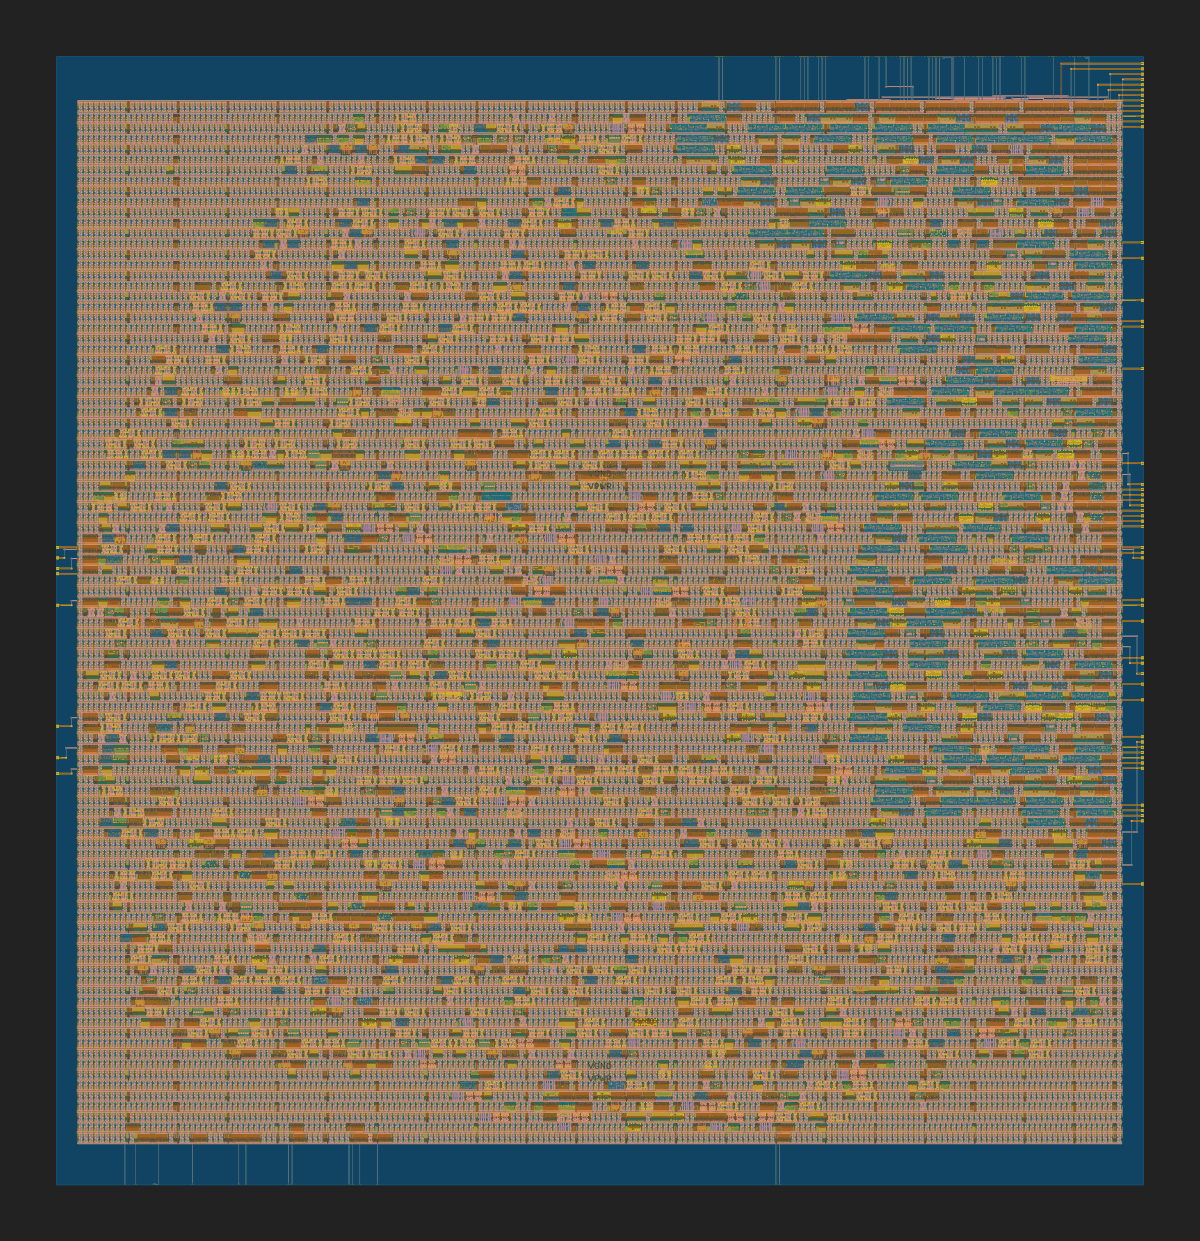

3D view saved to /content/anomaly_core_3d.html


In [52]:
import subprocess, sys, os
from pathlib import Path
from IPython.display import Image, display

def sh(cmd, **kw):
    r = subprocess.run(cmd, capture_output=True, text=True, **kw)
    if r.returncode != 0:
        print(r.stdout[-1500:], r.stderr[-1500:])
        raise RuntimeError(f"Failed: {' '.join(map(str, cmd))}")
    return r

sh([sys.executable, "-m", "pip", "install", "-q", "gdstk", "cairosvg", "jinja2"])
gds_list = list((Path(BASELINE["run_dir"]) / "final" / "gds").glob("*.gds"))
assert gds_list, f"No GDS in {BASELINE['run_dir']}/final/gds"
GDS = str(gds_list[0])
print("GDS:", GDS, f"({os.path.getsize(GDS)/1024:.0f} KB)")

import gdstk, cairosvg
top = gdstk.read_gds(GDS).top_level()[0]
svg, png = "/content/anomaly_core_layout.svg", "/content/anomaly_core_layout.png"
top.write_svg(svg)
cairosvg.svg2png(url=svg, write_to=png, output_width=1200)
display(Image(png))

# The interactive 3D viewer is optional: a failure here must not stop "Run all".
try:
    if not Path("/content/GDS2glTF").exists():
        sh(["git", "clone", "-q", "https://github.com/mbalestrini/GDS2glTF.git", "/content/GDS2glTF"])
        sh([sys.executable, "-m", "pip", "install", "-q", "-r", "/content/GDS2glTF/requirements.txt"])
    if not Path("/content/gds_viewer").exists():
        sh(["git", "clone", "-q", "https://github.com/proppy/gds_viewer.git", "/content/gds_viewer"])
    sh([sys.executable, "/content/GDS2glTF/gds2gltf.py", GDS])
    gltf = Path(GDS + ".gltf")
    if not gltf.exists():
        cand = list(Path(GDS).parent.glob("*.gltf")) + list(Path("/content").glob("*.gltf"))
        assert cand, "GDS2glTF did not produce a .gltf"
        gltf = cand[0]
    import jinja2
    tpl = jinja2.Environment(loader=jinja2.FileSystemLoader("/content/gds_viewer")).get_template("index.html")
    Path("/content/anomaly_core_3d.html").write_text(tpl.render(gltf_data=gltf.read_text()))
    print("3D view saved to /content/anomaly_core_3d.html")
except Exception as e:
    print("3D viewer skipped (optional):", e)

## 8. Artifact bundle

In [53]:
import zipfile, shutil
from pathlib import Path

bundle_files = ["anomaly_core.v", "test_anomaly_core.py", "test_saturation.py", "tb_dataset_full.py", "run_sim.py",
         "dataset.csv", "trained_params.json", "validation_vectors.json", "reference_results.json",
         "hw_accuracy_report.json", "results_table1.md", "signoff_baseline.md", "results_summary.json",
         "sweep_results.csv", "tool_versions.json",
         "/content/anomaly_core_layout.png", "/content/anomaly_core_3d.html"]
bundle_files += [str(p) for p in (Path(BASELINE["run_dir"]) / "final").glob("gds/*.gds")]
bundle_files += [str(p) for p in (Path(BASELINE["run_dir"]) / "final").glob("metrics.json")]

with zipfile.ZipFile("codeachip_artifacts.zip", "w", zipfile.ZIP_DEFLATED) as z:
    for fn in bundle_files:
        if Path(fn).exists():
            z.write(fn, arcname=Path(fn).name if "/final/" not in fn else f"run_{Path(fn).name}")
            print(f"  + {fn}")
        else:
            print(f"  - (missing) {fn}")
print("\nBundle:", Path("codeachip_artifacts.zip").resolve(), f"({Path('codeachip_artifacts.zip').stat().st_size/1024:.0f} KB)")
if BACKUP_DIR:
    shutil.copy("codeachip_artifacts.zip", BACKUP_DIR)
    print("Copied to", BACKUP_DIR)

  + anomaly_core.v
  + test_anomaly_core.py
  + test_saturation.py
  + tb_dataset_full.py
  + run_sim.py
  + dataset.csv
  + trained_params.json
  + validation_vectors.json
  + reference_results.json
  + hw_accuracy_report.json
  + results_table1.md
  + signoff_baseline.md
  + results_summary.json
  + sweep_results.csv
  + tool_versions.json
  + /content/anomaly_core_layout.png
  + /content/anomaly_core_3d.html
  + /content/flow_runs/base_acc32_bias16_40ns/runs/RUN_2026-10-09_00-45-08/final/gds/anomaly_core.gds
  + /content/flow_runs/base_acc32_bias16_40ns/runs/RUN_2026-10-09_00-45-08/final/metrics.json

Bundle: /content/codeachip_artifacts.zip (10773 KB)


In [54]:
from google.colab import files
files.download("/content/codeachip_artifacts.zip")

## 9. Conclusions and limitations

**What was demonstrated**
* The 32-bit extended accumulator is overflow-free by construction for 8-bit operands, and the saturation
  stage clamps correctly when it is made reachable (§3.2; the negative control wraps into a false negative).
* The RTL matches the Python reference bit-exactly on 1 000 validation vectors and on constrained-random
  stimulus (§3.3, 0 mismatches).
* The baseline reaches DRC = 0, LVS = 0 and positive setup/hold slack in all 9 PVT corners at 40 ns (§4–5).
* §6 quantifies the area cost of each accumulator width. Narrowing the accumulator saves 1.6-9.4 % of synthesised area;
  the live clamp costs +6.7 % (+1 558 µm², +27 cells) at 17 bits.

**Limitations**
* The dataset is synthetic; accuracy figures validate the hardware against the software model,
  not clinical performance. The RTL has high recall (0.874) but modest precision (0.468),
  a deliberate bias toward not missing alerts.
* 40 ns is the smallest period of the candidates tried (30, 35, 40 ns), not a proven minimum.
* The bit-exact functional check applies to the baseline configuration; sweep variants are compared on
  area, timing and power only.
* Both `acc17` sweep variants fail setup at 40 ns (WNS -0.845 ns without clamp, -1.356 ns with clamp), so they are not
  valid design points at the baseline clock (`timing_met = False` in `sweep_results.csv`). Setup slack across the sweep is
  not monotonic in `ACC_W`, so differences of a few ns should not be read as an accumulator-width effect.
* Extended checks: max-slew violations in the slow corner and one clock-root fanout violation remain
  (see §5); setup, hold, DRC and LVS are clean in all corners.
* Sky130 is a 130 nm teaching PDK; area and power are not representative of a production medical-device node.